<a href="https://colab.research.google.com/github/MRezaFallah/MRezaFallah/blob/main/DL_HW2_Q2_Lung_UNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# Question 2 - Step 1: Setup
# ============================================================

import os
import zipfile
import random
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms

from PIL import Image
from tqdm import tqdm

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch version:", torch.__version__)
print("Device:", device)

os.makedirs("outputs_q2", exist_ok=True)
os.makedirs("models_q2", exist_ok=True)
os.makedirs("data_q2", exist_ok=True)

print("Folders created.")

PyTorch version: 2.11.0+cu128
Device: cuda
Folders created.


In [2]:
# ============================================================
# Question 2 - Step 2: Download Dataset from Shared URL
# ============================================================

!pip install -q gdown

In [3]:
# Put your shared Google Drive URL here
url = "https://drive.google.com/file/d/1DshAzQMuyuEuJitc0Ng8lVvSAlM45v9H/view?usp=drive_link"

# Output zip name
output_zip = "lung_dataset.zip"

# Download
!gdown --fuzzy "$url" -O "$output_zip"

print("Downloaded file:", output_zip)

Downloading...
From (original): https://drive.google.com/uc?id=1DshAzQMuyuEuJitc0Ng8lVvSAlM45v9H
From (redirected): https://drive.google.com/uc?id=1DshAzQMuyuEuJitc0Ng8lVvSAlM45v9H&confirm=t&uuid=4fb91f3c-e403-4e35-ad24-ef3040b99de5
To: /content/lung_dataset.zip
100% 566M/566M [00:13<00:00, 41.4MB/s]
Downloaded file: lung_dataset.zip


In [4]:
# ============================================================
# Question 2 - Step 3: Unzip Dataset
# ============================================================

import zipfile
import os
from pathlib import Path

extract_dir = Path("data_q2/lung_dataset")
extract_dir.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile("lung_dataset.zip", "r") as zip_ref:
    zip_ref.extractall(extract_dir)

print("Dataset extracted to:", extract_dir)

Dataset extracted to: data_q2/lung_dataset


In [5]:
# ============================================================
# Question 2 - Step 4: Show Folder Structure
# ============================================================

for root, dirs, files_in_dir in os.walk(extract_dir):
    level = root.replace(str(extract_dir), "").count(os.sep)
    indent = " " * 4 * level
    print(f"{indent}{os.path.basename(root)}/")

    sub_indent = " " * 4 * (level + 1)
    for f in files_in_dir[:5]:
        print(f"{sub_indent}{f}")

    if level >= 3:
        dirs[:] = []

lung_dataset/
    CXR_png/
        CHNCXR_0142_0.png
        CHNCXR_0616_1.png
        CHNCXR_0501_1.png
        MCUCXR_0399_1.png
        CHNCXR_0431_1.png
    masks/
        CHNCXR_0092_0_mask.png
        CHNCXR_0443_1_mask.png
        CHNCXR_0445_1_mask.png
        MCUCXR_0301_1_mask.png
        MCUCXR_0083_0_mask.png


In [6]:
# ============================================================
# Question 2 - Step 5: Count Images, Masks, and Build Matched Pairs
# ============================================================

from pathlib import Path
import pandas as pd

# Dataset folders
image_dir = Path("data_q2/lung_dataset/CXR_png")
mask_dir = Path("data_q2/lung_dataset/masks")

# Accepted image extensions
image_extensions = [".png", ".jpg", ".jpeg"]

# Get all image files
image_paths = []
for ext in image_extensions:
    image_paths.extend(list(image_dir.glob(f"*{ext}")))

# Get all mask files
mask_paths = []
for ext in image_extensions:
    mask_paths.extend(list(mask_dir.glob(f"*{ext}")))

print("Original number of images:", len(image_paths))
print("Original number of masks:", len(mask_paths))

# ------------------------------------------------------------
# Create dictionary for images
# Example image name:
# CHNCXR_0142_0.png
# Key becomes:
# CHNCXR_0142_0
# ------------------------------------------------------------

image_dict = {}

for img_path in image_paths:
    key = img_path.stem
    image_dict[key] = img_path

# ------------------------------------------------------------
# Match masks with images
# Example mask name:
# CHNCXR_0092_0_mask.png
# Key becomes:
# CHNCXR_0092_0
# ------------------------------------------------------------

matched_pairs = []
unmatched_masks = []

for mask_path in mask_paths:
    mask_key = mask_path.stem

    if mask_key.endswith("_mask"):
        image_key = mask_key.replace("_mask", "")
    else:
        image_key = mask_key

    if image_key in image_dict:
        matched_pairs.append({
            "image_id": image_key,
            "image_path": str(image_dict[image_key]),
            "mask_path": str(mask_path)
        })
    else:
        unmatched_masks.append(str(mask_path))

matched_df = pd.DataFrame(matched_pairs)

print("\nNumber of matched image-mask pairs:", len(matched_df))
print("Number of masks without matching image:", len(unmatched_masks))
print("Number of images without mask:", len(image_paths) - len(matched_df))

# Show first rows
display(matched_df.head())

# Save matched pairs for later steps
matched_df.to_csv("outputs_q2/matched_image_mask_pairs.csv", index=False)

print("\nSaved matched pairs to:")
print("outputs_q2/matched_image_mask_pairs.csv")

Original number of images: 800
Original number of masks: 704

Number of matched image-mask pairs: 704
Number of masks without matching image: 0
Number of images without mask: 96


,image_id,image_path,mask_path
0,CHNCXR_0092_0,data_q2/lung_dataset/CXR_png/CHNCXR_0092_0.png,data_q2/lung_dataset/masks/CHNCXR_0092_0_mask.png
1,CHNCXR_0443_1,data_q2/lung_dataset/CXR_png/CHNCXR_0443_1.png,data_q2/lung_dataset/masks/CHNCXR_0443_1_mask.png
2,CHNCXR_0445_1,data_q2/lung_dataset/CXR_png/CHNCXR_0445_1.png,data_q2/lung_dataset/masks/CHNCXR_0445_1_mask.png
3,MCUCXR_0301_1,data_q2/lung_dataset/CXR_png/MCUCXR_0301_1.png,data_q2/lung_dataset/masks/MCUCXR_0301_1_mask.png
4,MCUCXR_0083_0,data_q2/lung_dataset/CXR_png/MCUCXR_0083_0.png,data_q2/lung_dataset/masks/MCUCXR_0083_0_mask.png



Saved matched pairs to:
outputs_q2/matched_image_mask_pairs.csv


Final number of image-mask pairs: 704
Selected image size: 128 x 128

Dataset split:
Train size: 563
Validation size: 70
Test size: 71

DataLoaders created.
Batch size: 8

One image batch shape: torch.Size([8, 1, 128, 128])
One mask batch shape: torch.Size([8, 1, 128, 128])
Image min/max: 0.0 1.0
Mask unique values: tensor([0., 1.])


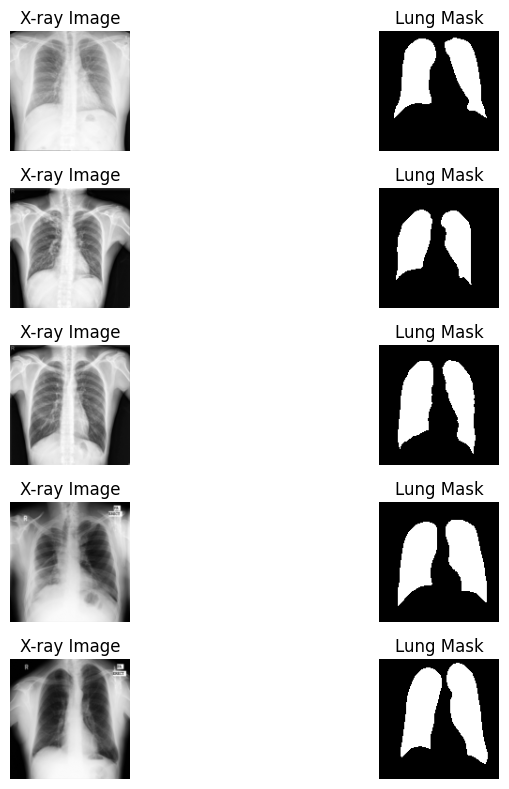

Saved sample figure to:
outputs_q2/five_image_mask_samples.png


In [7]:
# ============================================================
# Question 2 - Step 6: Dataset Class, Resize, Normalize, Split
# ============================================================

from PIL import Image
from torch.utils.data import Dataset, DataLoader, Subset
import numpy as np
import torch
import matplotlib.pyplot as plt

IMAGE_SIZE = 128
BATCH_SIZE_Q2 = 8

# ------------------------------------------------------------
# Custom Dataset for Lung X-ray Segmentation
# ------------------------------------------------------------

class LungSegmentationDataset(Dataset):
    def __init__(self, dataframe, image_size=128):
        self.dataframe = dataframe.reset_index(drop=True)
        self.image_size = image_size

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        image_path = self.dataframe.loc[idx, "image_path"]
        mask_path = self.dataframe.loc[idx, "mask_path"]

        # Load image and mask as grayscale
        image = Image.open(image_path).convert("L")
        mask = Image.open(mask_path).convert("L")

        # Resize image and mask
        image = image.resize((self.image_size, self.image_size), Image.BILINEAR)
        mask = mask.resize((self.image_size, self.image_size), Image.NEAREST)

        # Convert to numpy arrays
        image = np.array(image, dtype=np.float32)
        mask = np.array(mask, dtype=np.float32)

        # Normalize image to [0, 1]
        image = image / 255.0

        # Convert mask to binary: 0 or 1
        mask = mask / 255.0
        mask = (mask > 0.5).astype(np.float32)

        # Add channel dimension: [H, W] -> [1, H, W]
        image = np.expand_dims(image, axis=0)
        mask = np.expand_dims(mask, axis=0)

        # Convert to tensor
        image = torch.tensor(image, dtype=torch.float32)
        mask = torch.tensor(mask, dtype=torch.float32)

        return image, mask


# ------------------------------------------------------------
# Build full dataset using only matched image-mask pairs
# matched_df must already exist from Step 5
# ------------------------------------------------------------

full_lung_dataset = LungSegmentationDataset(
    matched_df,
    image_size=IMAGE_SIZE
)

print("Final number of image-mask pairs:", len(full_lung_dataset))
print("Selected image size:", IMAGE_SIZE, "x", IMAGE_SIZE)


# ------------------------------------------------------------
# Train / Validation / Test split = 80% / 10% / 10%
# ------------------------------------------------------------

total_size = len(full_lung_dataset)

train_size_q2 = int(0.8 * total_size)
val_size_q2 = int(0.1 * total_size)
test_size_q2 = total_size - train_size_q2 - val_size_q2

indices = np.arange(total_size)
np.random.seed(SEED)
np.random.shuffle(indices)

train_indices_q2 = indices[:train_size_q2]
val_indices_q2 = indices[train_size_q2:train_size_q2 + val_size_q2]
test_indices_q2 = indices[train_size_q2 + val_size_q2:]

train_dataset_q2 = Subset(full_lung_dataset, train_indices_q2)
val_dataset_q2 = Subset(full_lung_dataset, val_indices_q2)
test_dataset_q2 = Subset(full_lung_dataset, test_indices_q2)

print("\nDataset split:")
print("Train size:", len(train_dataset_q2))
print("Validation size:", len(val_dataset_q2))
print("Test size:", len(test_dataset_q2))


# ------------------------------------------------------------
# Create DataLoaders
# ------------------------------------------------------------

train_loader_q2 = DataLoader(
    train_dataset_q2,
    batch_size=BATCH_SIZE_Q2,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader_q2 = DataLoader(
    val_dataset_q2,
    batch_size=BATCH_SIZE_Q2,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader_q2 = DataLoader(
    test_dataset_q2,
    batch_size=BATCH_SIZE_Q2,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("\nDataLoaders created.")
print("Batch size:", BATCH_SIZE_Q2)


# ------------------------------------------------------------
# Check one batch
# ------------------------------------------------------------

images_batch, masks_batch = next(iter(train_loader_q2))

print("\nOne image batch shape:", images_batch.shape)
print("One mask batch shape:", masks_batch.shape)
print("Image min/max:", images_batch.min().item(), images_batch.max().item())
print("Mask unique values:", torch.unique(masks_batch))


# ------------------------------------------------------------
# Show 5 image-mask pairs
# ------------------------------------------------------------

plt.figure(figsize=(10, 8))

for i in range(5):
    image, mask = full_lung_dataset[i]

    image_np = image.squeeze().numpy()
    mask_np = mask.squeeze().numpy()

    plt.subplot(5, 2, 2 * i + 1)
    plt.imshow(image_np, cmap="gray")
    plt.title("X-ray Image")
    plt.axis("off")

    plt.subplot(5, 2, 2 * i + 2)
    plt.imshow(mask_np, cmap="gray")
    plt.title("Lung Mask")
    plt.axis("off")

plt.tight_layout()
plt.savefig("outputs_q2/five_image_mask_samples.png", dpi=300)
plt.show()

print("Saved sample figure to:")
print("outputs_q2/five_image_mask_samples.png")


Augmented training dataset is ready.
Train size: 563
Validation size: 70
Test size: 71
Augmentation is applied only to the training set.


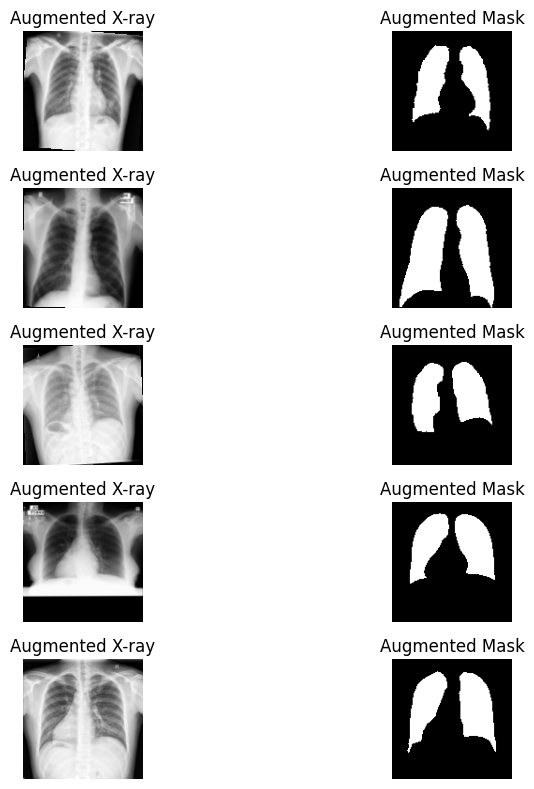

Saved augmented sample figure to:
outputs_q2/five_augmented_image_mask_samples.png


In [8]:
# ============================================================
# Question 2 - Step 7: Data Augmentation for Training Set Only
# ============================================================

import random
import numpy as np
import torch
from PIL import Image, ImageEnhance
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import torchvision.transforms.functional as TF

# ------------------------------------------------------------
# Augmented Dataset
# The same geometric transforms are applied to both image and mask.
# Brightness/contrast changes are applied only to the image.
# ------------------------------------------------------------

class LungSegmentationAugDataset(Dataset):
    def __init__(self, dataframe, image_size=128, augment=False):
        self.dataframe = dataframe.reset_index(drop=True)
        self.image_size = image_size
        self.augment = augment

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        image_path = self.dataframe.loc[idx, "image_path"]
        mask_path = self.dataframe.loc[idx, "mask_path"]

        # Load as grayscale
        image = Image.open(image_path).convert("L")
        mask = Image.open(mask_path).convert("L")

        # Resize
        image = image.resize((self.image_size, self.image_size), Image.BILINEAR)
        mask = mask.resize((self.image_size, self.image_size), Image.NEAREST)

        # -----------------------------
        # Data augmentation: TRAIN only
        # -----------------------------
        if self.augment:
            # 1. Horizontal flip
            if random.random() < 0.5:
                image = TF.hflip(image)
                mask = TF.hflip(mask)

            # 2. Random rotation
            if random.random() < 0.5:
                angle = random.uniform(-10, 10)
                image = TF.rotate(image, angle, interpolation=TF.InterpolationMode.BILINEAR)
                mask = TF.rotate(mask, angle, interpolation=TF.InterpolationMode.NEAREST)

            # 3. Brightness and contrast change: image only
            if random.random() < 0.5:
                brightness_factor = random.uniform(0.85, 1.15)
                contrast_factor = random.uniform(0.85, 1.15)

                image = ImageEnhance.Brightness(image).enhance(brightness_factor)
                image = ImageEnhance.Contrast(image).enhance(contrast_factor)

        # Convert to numpy
        image = np.array(image, dtype=np.float32)
        mask = np.array(mask, dtype=np.float32)

        # Normalize image to [0, 1]
        image = image / 255.0

        # Binary mask: 0 or 1
        mask = mask / 255.0
        mask = (mask > 0.5).astype(np.float32)

        # Add channel dimension: [H, W] -> [1, H, W]
        image = np.expand_dims(image, axis=0)
        mask = np.expand_dims(mask, axis=0)

        # Convert to tensor
        image = torch.tensor(image, dtype=torch.float32)
        mask = torch.tensor(mask, dtype=torch.float32)

        return image, mask


# ------------------------------------------------------------
# Build train/val/test dataframes using previous split indices
# ------------------------------------------------------------

train_df_q2 = matched_df.iloc[train_indices_q2].reset_index(drop=True)
val_df_q2 = matched_df.iloc[val_indices_q2].reset_index(drop=True)
test_df_q2 = matched_df.iloc[test_indices_q2].reset_index(drop=True)

# Augmentation is applied only to training data
train_aug_dataset_q2 = LungSegmentationAugDataset(
    train_df_q2,
    image_size=IMAGE_SIZE,
    augment=True
)

val_dataset_q2_noaug = LungSegmentationAugDataset(
    val_df_q2,
    image_size=IMAGE_SIZE,
    augment=False
)

test_dataset_q2_noaug = LungSegmentationAugDataset(
    test_df_q2,
    image_size=IMAGE_SIZE,
    augment=False
)

train_aug_loader_q2 = DataLoader(
    train_aug_dataset_q2,
    batch_size=BATCH_SIZE_Q2,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader_q2 = DataLoader(
    val_dataset_q2_noaug,
    batch_size=BATCH_SIZE_Q2,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader_q2 = DataLoader(
    test_dataset_q2_noaug,
    batch_size=BATCH_SIZE_Q2,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Augmented training dataset is ready.")
print("Train size:", len(train_aug_dataset_q2))
print("Validation size:", len(val_dataset_q2_noaug))
print("Test size:", len(test_dataset_q2_noaug))
print("Augmentation is applied only to the training set.")


# ------------------------------------------------------------
# Show 5 augmented training samples
# ------------------------------------------------------------

plt.figure(figsize=(10, 8))

for i in range(5):
    image, mask = train_aug_dataset_q2[i]

    image_np = image.squeeze().numpy()
    mask_np = mask.squeeze().numpy()

    plt.subplot(5, 2, 2 * i + 1)
    plt.imshow(image_np, cmap="gray")
    plt.title("Augmented X-ray")
    plt.axis("off")

    plt.subplot(5, 2, 2 * i + 2)
    plt.imshow(mask_np, cmap="gray")
    plt.title("Augmented Mask")
    plt.axis("off")

plt.tight_layout()
plt.savefig("outputs_q2/five_augmented_image_mask_samples.png", dpi=300)
plt.show()

print("Saved augmented sample figure to:")
print("outputs_q2/five_augmented_image_mask_samples.png")


In [9]:
# ============================================================
# Question 2 - Step 8: Lightweight U-Net Models
# With Skip Connections and Without Skip Connections
# ============================================================

import torch
import torch.nn as nn

# ------------------------------------------------------------
# 1. Basic convolution block
# Conv -> BatchNorm -> ReLU -> Conv -> BatchNorm -> ReLU
# ------------------------------------------------------------

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(DoubleConv, self).__init__()

        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)


# ------------------------------------------------------------
# 2. Lightweight U-Net
# use_skip=True  -> normal U-Net with skip connections
# use_skip=False -> same encoder-decoder structure without skip connections
# ------------------------------------------------------------

class LightweightUNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, base_filters=16, use_skip=True):
        super(LightweightUNet, self).__init__()

        self.use_skip = use_skip

        # Encoder
        self.enc1 = DoubleConv(in_channels, base_filters)             # 16
        self.enc2 = DoubleConv(base_filters, base_filters * 2)        # 32
        self.enc3 = DoubleConv(base_filters * 2, base_filters * 4)    # 64
        self.enc4 = DoubleConv(base_filters * 4, base_filters * 8)    # 128

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Bottleneck
        self.bottleneck = DoubleConv(base_filters * 8, base_filters * 16)  # 256

        # Decoder upsampling
        self.up4 = nn.ConvTranspose2d(base_filters * 16, base_filters * 8, kernel_size=2, stride=2)
        self.up3 = nn.ConvTranspose2d(base_filters * 8, base_filters * 4, kernel_size=2, stride=2)
        self.up2 = nn.ConvTranspose2d(base_filters * 4, base_filters * 2, kernel_size=2, stride=2)
        self.up1 = nn.ConvTranspose2d(base_filters * 2, base_filters, kernel_size=2, stride=2)

        # Decoder convolution blocks
        if self.use_skip:
            self.dec4 = DoubleConv(base_filters * 16, base_filters * 8)
            self.dec3 = DoubleConv(base_filters * 8, base_filters * 4)
            self.dec2 = DoubleConv(base_filters * 4, base_filters * 2)
            self.dec1 = DoubleConv(base_filters * 2, base_filters)
        else:
            self.dec4 = DoubleConv(base_filters * 8, base_filters * 8)
            self.dec3 = DoubleConv(base_filters * 4, base_filters * 4)
            self.dec2 = DoubleConv(base_filters * 2, base_filters * 2)
            self.dec1 = DoubleConv(base_filters, base_filters)

        # Output layer
        # Sigmoid is used because this is binary segmentation:
        # each pixel is either lung region = 1 or background = 0.
        self.final_conv = nn.Conv2d(base_filters, out_channels, kernel_size=1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)                  # 128x128
        e2 = self.enc2(self.pool(e1))      # 64x64
        e3 = self.enc3(self.pool(e2))      # 32x32
        e4 = self.enc4(self.pool(e3))      # 16x16

        # Bottleneck
        b = self.bottleneck(self.pool(e4)) # 8x8

        # Decoder stage 4
        d4 = self.up4(b)                   # 16x16
        if self.use_skip:
            d4 = torch.cat([d4, e4], dim=1)
        d4 = self.dec4(d4)

        # Decoder stage 3
        d3 = self.up3(d4)                  # 32x32
        if self.use_skip:
            d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        # Decoder stage 2
        d2 = self.up2(d3)                  # 64x64
        if self.use_skip:
            d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        # Decoder stage 1
        d1 = self.up1(d2)                  # 128x128
        if self.use_skip:
            d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        output = self.final_conv(d1)
        output = self.sigmoid(output)

        return output


# ------------------------------------------------------------
# 3. Parameter counting function
# ------------------------------------------------------------

def count_trainable_parameters(model):
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total_params, trainable_params


# ------------------------------------------------------------
# 4. Create both models
# ------------------------------------------------------------

unet_skip = LightweightUNet(
    in_channels=1,
    out_channels=1,
    base_filters=16,
    use_skip=True
).to(device)

unet_no_skip = LightweightUNet(
    in_channels=1,
    out_channels=1,
    base_filters=16,
    use_skip=False
).to(device)


# ------------------------------------------------------------
# 5. Print model parameter counts
# ------------------------------------------------------------

skip_total, skip_trainable = count_trainable_parameters(unet_skip)
noskip_total, noskip_trainable = count_trainable_parameters(unet_no_skip)

print("Lightweight U-Net WITH skip connections")
print("--------------------------------------")
print(f"Total parameters: {skip_total:,}")
print(f"Trainable parameters: {skip_trainable:,}")

print("\nLightweight U-Net WITHOUT skip connections")
print("-----------------------------------------")
print(f"Total parameters: {noskip_total:,}")
print(f"Trainable parameters: {noskip_trainable:,}")


# ------------------------------------------------------------
# 6. Test forward pass with one batch
# ------------------------------------------------------------

sample_images, sample_masks = next(iter(train_aug_loader_q2))
sample_images = sample_images.to(device)

with torch.no_grad():
    skip_output = unet_skip(sample_images)
    noskip_output = unet_no_skip(sample_images)

print("\nInput batch shape:", sample_images.shape)
print("Skip U-Net output shape:", skip_output.shape)
print("No-skip U-Net output shape:", noskip_output.shape)
print("Output min/max for skip U-Net:", skip_output.min().item(), skip_output.max().item())
print("Output min/max for no-skip U-Net:", noskip_output.min().item(), noskip_output.max().item())

print("\nStep 8 completed.")


Lightweight U-Net WITH skip connections
--------------------------------------
Total parameters: 1,942,289
Trainable parameters: 1,942,289

Lightweight U-Net WITHOUT skip connections
-----------------------------------------
Total parameters: 1,746,449
Trainable parameters: 1,746,449

Input batch shape: torch.Size([8, 1, 128, 128])
Skip U-Net output shape: torch.Size([8, 1, 128, 128])
No-skip U-Net output shape: torch.Size([8, 1, 128, 128])
Output min/max for skip U-Net: 0.3273750841617584 0.9976382255554199
Output min/max for no-skip U-Net: 0.15986229479312897 0.9506223201751709

Step 8 completed.


In [10]:
# ============================================================
# Question 2 - Step 9: Loss Functions and Evaluation Metrics
# Dice Loss, BCE + Dice Loss, Dice Coefficient, IoU, Accuracy
# ============================================================

import torch
import torch.nn as nn

SMOOTH = 1e-6


# ------------------------------------------------------------
# 1. Dice Coefficient
# Measures overlap between predicted mask and ground-truth mask.
# Higher is better. Best value = 1.
# ------------------------------------------------------------

def dice_coefficient(preds, targets, threshold=0.5, smooth=SMOOTH):
    """
    preds: model output after sigmoid, shape [B, 1, H, W]
    targets: binary masks, shape [B, 1, H, W]
    """
    preds = (preds >= threshold).float()
    targets = targets.float()

    preds = preds.view(preds.size(0), -1)
    targets = targets.view(targets.size(0), -1)

    intersection = (preds * targets).sum(dim=1)
    union = preds.sum(dim=1) + targets.sum(dim=1)

    dice = (2.0 * intersection + smooth) / (union + smooth)

    return dice.mean()


# ------------------------------------------------------------
# 2. Soft Dice Coefficient
# Used inside Dice Loss.
# It uses probabilities instead of thresholded masks.
# ------------------------------------------------------------

def soft_dice_coefficient(preds, targets, smooth=SMOOTH):
    preds = preds.float()
    targets = targets.float()

    preds = preds.view(preds.size(0), -1)
    targets = targets.view(targets.size(0), -1)

    intersection = (preds * targets).sum(dim=1)
    union = preds.sum(dim=1) + targets.sum(dim=1)

    dice = (2.0 * intersection + smooth) / (union + smooth)

    return dice.mean()


# ------------------------------------------------------------
# 3. Dice Loss
# Lower is better. Best value = 0.
# ------------------------------------------------------------

class DiceLoss(nn.Module):
    def __init__(self):
        super(DiceLoss, self).__init__()

    def forward(self, preds, targets):
        return 1.0 - soft_dice_coefficient(preds, targets)


# ------------------------------------------------------------
# 4. BCE + Dice Loss
# BCE helps pixel-wise classification.
# Dice helps mask overlap.
# ------------------------------------------------------------

class BCEDiceLoss(nn.Module):
    def __init__(self, bce_weight=0.5, dice_weight=0.5):
        super(BCEDiceLoss, self).__init__()
        self.bce = nn.BCELoss()
        self.dice = DiceLoss()
        self.bce_weight = bce_weight
        self.dice_weight = dice_weight

    def forward(self, preds, targets):
        bce_loss = self.bce(preds, targets)
        dice_loss = self.dice(preds, targets)

        total_loss = (self.bce_weight * bce_loss) + (self.dice_weight * dice_loss)

        return total_loss


# ------------------------------------------------------------
# 5. IoU / Jaccard Score
# Measures intersection over union.
# Higher is better. Best value = 1.
# ------------------------------------------------------------

def iou_score(preds, targets, threshold=0.5, smooth=SMOOTH):
    preds = (preds >= threshold).float()
    targets = targets.float()

    preds = preds.view(preds.size(0), -1)
    targets = targets.view(targets.size(0), -1)

    intersection = (preds * targets).sum(dim=1)
    union = preds.sum(dim=1) + targets.sum(dim=1) - intersection

    iou = (intersection + smooth) / (union + smooth)

    return iou.mean()


# ------------------------------------------------------------
# 6. Pixel Accuracy
# Percentage of correctly classified pixels.
# ------------------------------------------------------------

def pixel_accuracy(preds, targets, threshold=0.5):
    preds = (preds >= threshold).float()
    targets = targets.float()

    correct = (preds == targets).float().sum()
    total = torch.numel(targets)

    return correct / total


# ------------------------------------------------------------
# 7. Test loss functions and metrics on one batch
# ------------------------------------------------------------

dice_loss_fn = DiceLoss()
bce_dice_loss_fn = BCEDiceLoss(bce_weight=0.5, dice_weight=0.5)

sample_images, sample_masks = next(iter(train_aug_loader_q2))
sample_images = sample_images.to(device)
sample_masks = sample_masks.to(device)

unet_skip.eval()

with torch.no_grad():
    sample_outputs = unet_skip(sample_images)

test_dice_loss = dice_loss_fn(sample_outputs, sample_masks)
test_bce_dice_loss = bce_dice_loss_fn(sample_outputs, sample_masks)
test_dice = dice_coefficient(sample_outputs, sample_masks)
test_iou = iou_score(sample_outputs, sample_masks)
test_acc = pixel_accuracy(sample_outputs, sample_masks)

print("Step 9 completed.")
print("-----------------")
print(f"Dice Loss:      {test_dice_loss.item():.4f}")
print(f"BCE+Dice Loss:  {test_bce_dice_loss.item():.4f}")
print(f"Dice Coef:      {test_dice.item():.4f}")
print(f"IoU:            {test_iou.item():.4f}")
print(f"Pixel Accuracy: {test_acc.item():.4f}")


Step 9 completed.
-----------------
Dice Loss:      0.6527
BCE+Dice Loss:  0.6982
Dice Coef:      0.4079
IoU:            0.2596
Pixel Accuracy: 0.2596


In [11]:
# ============================================================
# Question 2 - Step 10: Training and Validation Utilities
# EarlyStopping + Epoch Metrics + Plots
# ============================================================

import copy
import time
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.optim as optim
from tqdm import tqdm


# ------------------------------------------------------------
# 1. Run one training epoch
# ------------------------------------------------------------

def train_one_epoch_segmentation(model, data_loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    running_dice = 0.0
    running_iou = 0.0
    running_acc = 0.0

    total_batches = 0

    for images, masks in tqdm(data_loader, desc="Training", leave=False):
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, masks)

        loss.backward()
        optimizer.step()

        with torch.no_grad():
            batch_dice = dice_coefficient(outputs, masks)
            batch_iou = iou_score(outputs, masks)
            batch_acc = pixel_accuracy(outputs, masks)

        running_loss += loss.item()
        running_dice += batch_dice.item()
        running_iou += batch_iou.item()
        running_acc += batch_acc.item()

        total_batches += 1

    epoch_loss = running_loss / total_batches
    epoch_dice = running_dice / total_batches
    epoch_iou = running_iou / total_batches
    epoch_acc = running_acc / total_batches

    return epoch_loss, epoch_dice, epoch_iou, epoch_acc


# ------------------------------------------------------------
# 2. Run one validation/test epoch
# ------------------------------------------------------------

def evaluate_segmentation_model(model, data_loader, criterion, device, desc="Validation"):
    model.eval()

    running_loss = 0.0
    running_dice = 0.0
    running_iou = 0.0
    running_acc = 0.0

    total_batches = 0

    with torch.no_grad():
        for images, masks in tqdm(data_loader, desc=desc, leave=False):
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)
            loss = criterion(outputs, masks)

            batch_dice = dice_coefficient(outputs, masks)
            batch_iou = iou_score(outputs, masks)
            batch_acc = pixel_accuracy(outputs, masks)

            running_loss += loss.item()
            running_dice += batch_dice.item()
            running_iou += batch_iou.item()
            running_acc += batch_acc.item()

            total_batches += 1

    epoch_loss = running_loss / total_batches
    epoch_dice = running_dice / total_batches
    epoch_iou = running_iou / total_batches
    epoch_acc = running_acc / total_batches

    return epoch_loss, epoch_dice, epoch_iou, epoch_acc


# ------------------------------------------------------------
# 3. Full training function with EarlyStopping
# ------------------------------------------------------------

def train_segmentation_model(
    model,
    train_loader,
    val_loader,
    criterion,
    model_name,
    num_epochs=20,
    learning_rate=0.001,
    weight_decay=1e-4,
    patience=5
):
    model = model.to(device)

    optimizer = optim.AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay
    )

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=2
    )

    history = {
        "loss": [],
        "val_loss": [],
        "dice_coef": [],
        "val_dice_coef": [],
        "iou": [],
        "val_iou": [],
        "accuracy": [],
        "val_accuracy": [],
        "learning_rate": []
    }

    best_val_loss = float("inf")
    best_val_dice = 0.0
    best_model_state = copy.deepcopy(model.state_dict())

    early_stop_counter = 0
    start_time = time.time()

    print(f"\nTraining model: {model_name}")
    print(f"Epochs: {num_epochs}")
    print(f"Learning rate: {learning_rate}")
    print(f"Batch size: {BATCH_SIZE_Q2}")
    print(f"Weight decay: {weight_decay}")
    print(f"EarlyStopping patience: {patience}")
    print(f"Loss function: {criterion.__class__.__name__}")

    for epoch in range(num_epochs):
        print(f"\nEpoch [{epoch + 1}/{num_epochs}]")

        train_loss, train_dice, train_iou, train_acc = train_one_epoch_segmentation(
            model=model,
            data_loader=train_loader,
            criterion=criterion,
            optimizer=optimizer,
            device=device
        )

        val_loss, val_dice, val_iou, val_acc = evaluate_segmentation_model(
            model=model,
            data_loader=val_loader,
            criterion=criterion,
            device=device,
            desc="Validation"
        )

        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]["lr"]

        history["loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["dice_coef"].append(train_dice)
        history["val_dice_coef"].append(val_dice)
        history["iou"].append(train_iou)
        history["val_iou"].append(val_iou)
        history["accuracy"].append(train_acc)
        history["val_accuracy"].append(val_acc)
        history["learning_rate"].append(current_lr)

        print(f"Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
        print(f"Dice: {train_dice:.4f} | Val Dice: {val_dice:.4f}")
        print(f"IoU:  {train_iou:.4f} | Val IoU:  {val_iou:.4f}")
        print(f"Acc:  {train_acc:.4f} | Val Acc:  {val_acc:.4f}")
        print(f"Current LR: {current_lr:.8f}")

        # EarlyStopping based on validation loss
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_val_dice = val_dice
            best_model_state = copy.deepcopy(model.state_dict())
            torch.save(model.state_dict(), f"models_q2/best_{model_name}.pth")
            early_stop_counter = 0
            print("Best model saved.")
        else:
            early_stop_counter += 1
            print(f"No improvement. EarlyStopping counter: {early_stop_counter}/{patience}")

        if early_stop_counter >= patience:
            print("EarlyStopping activated.")
            break

    elapsed_time = time.time() - start_time

    model.load_state_dict(best_model_state)

    history_df = pd.DataFrame(history)
    history_df.to_csv(f"outputs_q2/history_{model_name}.csv", index=False)

    print("\nTraining completed.")
    print(f"Best validation loss: {best_val_loss:.4f}")
    print(f"Validation Dice at best loss: {best_val_dice:.4f}")
    print(f"Training time: {elapsed_time:.2f} seconds")
    print(f"History saved to: outputs_q2/history_{model_name}.csv")
    print(f"Best model saved to: models_q2/best_{model_name}.pth")

    return model, history, elapsed_time


# ------------------------------------------------------------
# 4. Plot training curves
# ------------------------------------------------------------

def plot_segmentation_history(history, model_name):
    epochs = range(1, len(history["loss"]) + 1)

    # Loss curve
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["loss"], label="Training Loss")
    plt.plot(epochs, history["val_loss"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Training Loss - Validation Loss ({model_name})")
    plt.legend()
    plt.grid(True)
    plt.savefig(f"outputs_q2/loss_curve_{model_name}.png", dpi=300)
    plt.show()

    # Dice curve
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["dice_coef"], label="Training Dice")
    plt.plot(epochs, history["val_dice_coef"], label="Validation Dice")
    plt.xlabel("Epoch")
    plt.ylabel("Dice Coefficient")
    plt.title(f"Training Dice - Validation Dice ({model_name})")
    plt.legend()
    plt.grid(True)
    plt.savefig(f"outputs_q2/dice_curve_{model_name}.png", dpi=300)
    plt.show()

    # IoU curve
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["iou"], label="Training IoU")
    plt.plot(epochs, history["val_iou"], label="Validation IoU")
    plt.xlabel("Epoch")
    plt.ylabel("IoU")
    plt.title(f"Training IoU - Validation IoU ({model_name})")
    plt.legend()
    plt.grid(True)
    plt.savefig(f"outputs_q2/iou_curve_{model_name}.png", dpi=300)
    plt.show()

    # Accuracy curve
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["accuracy"], label="Training Accuracy")
    plt.plot(epochs, history["val_accuracy"], label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Pixel Accuracy")
    plt.title(f"Training Accuracy - Validation Accuracy ({model_name})")
    plt.legend()
    plt.grid(True)
    plt.savefig(f"outputs_q2/accuracy_curve_{model_name}.png", dpi=300)
    plt.show()


print("Step 10 completed.")
print("Training utilities are ready.")


Step 10 completed.
Training utilities are ready.



Training model: unet_skip_dice_loss
Epochs: 20
Learning rate: 0.001
Batch size: 8
Weight decay: 0.0001
EarlyStopping patience: 5
Loss function: DiceLoss

Epoch [1/20]


Loss: 0.3734 | Val Loss: 0.2639
Dice: 0.8682 | Val Dice: 0.9187
IoU:  0.7808 | Val IoU:  0.8510
Acc:  0.9260 | Val Acc:  0.9566
Current LR: 0.00100000
Best model saved.

Epoch [2/20]


Loss: 0.2327 | Val Loss: 0.1946
Dice: 0.9366 | Val Dice: 0.9326
IoU:  0.8820 | Val IoU:  0.8746
Acc:  0.9682 | Val Acc:  0.9644
Current LR: 0.00100000
Best model saved.

Epoch [3/20]


Loss: 0.1526 | Val Loss: 0.1269
Dice: 0.9482 | Val Dice: 0.9511
IoU:  0.9028 | Val IoU:  0.9074
Acc:  0.9742 | Val Acc:  0.9746
Current LR: 0.00100000
Best model saved.

Epoch [4/20]


Loss: 0.1124 | Val Loss: 0.0965
Dice: 0.9463 | Val Dice: 0.9535
IoU:  0.9002 | Val IoU:  0.9120
Acc:  0.9736 | Val Acc:  0.9761
Current LR: 0.00100000
Best model saved.

Epoch [5/20]


...

Loss: 0.0429 | Val Loss: 0.0387
Dice: 0.9601 | Val Dice: 0.9640
IoU:  0.9243 | Val IoU:  0.9313
Acc:  0.9802 | Val Acc:  0.9819
Current LR: 0.00100000
Best model saved.

Epoch [17/20]


Loss: 0.0417 | Val Loss: 0.0373
Dice: 0.9611 | Val Dice: 0.9650
IoU:  0.9262 | Val IoU:  0.9332
Acc:  0.9808 | Val Acc:  0.9825
Current LR: 0.00100000
Best model saved.

Epoch [18/20]


Loss: 0.0413 | Val Loss: 0.0402
Dice: 0.9611 | Val Dice: 0.9622
IoU:  0.9261 | Val IoU:  0.9279
Acc:  0.9808 | Val Acc:  0.9809
Current LR: 0.00100000
No improvement. EarlyStopping counter: 1/5

Epoch [19/20]


Loss: 0.0408 | Val Loss: 0.0382
Dice: 0.9613 | Val Dice: 0.9637
IoU:  0.9266 | Val IoU:  0.9308
Acc:  0.9809 | Val Acc:  0.9818
Current LR: 0.00100000
No improvement. EarlyStopping counter: 2/5

Epoch [20/20]


Loss: 0.0397 | Val Loss: 0.0367
Dice: 0.9622 | Val Dice: 0.9650
IoU:  0.9282 | Val IoU:  0.9332
Acc:  0.9813 | Val Acc:  0.9824
Current LR: 0.00100000
Best model saved.

Training completed.
Best validation loss: 0.0367
Validation Dice at best loss: 0.9650
Training time: 196.08 seconds
History saved to: outputs_q2/history_unet_skip_dice_loss.csv
Best model saved to: models_q2/best_unet_skip_dice_loss.pth


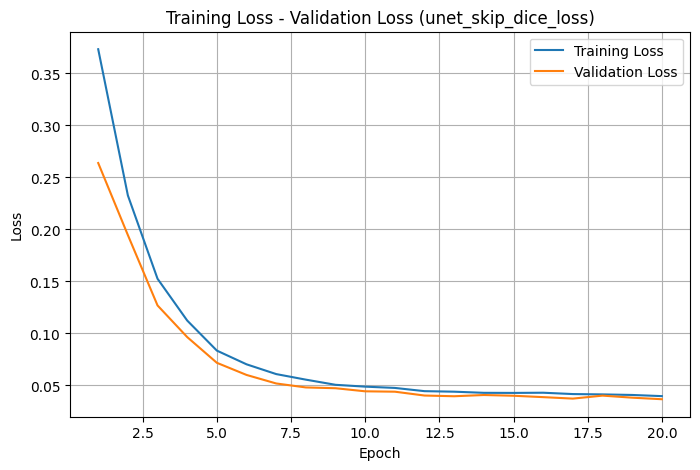

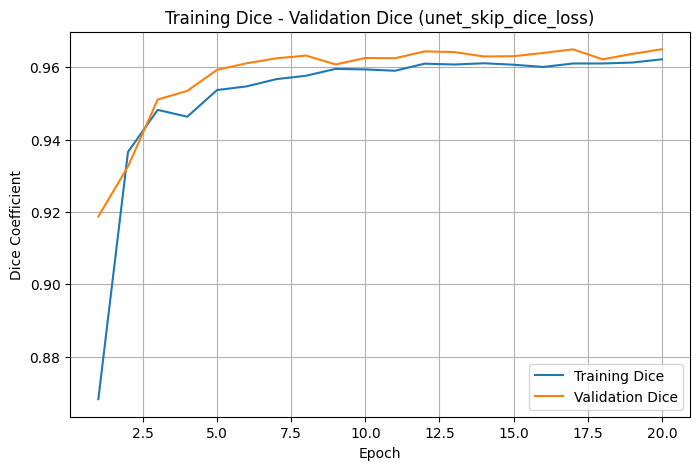

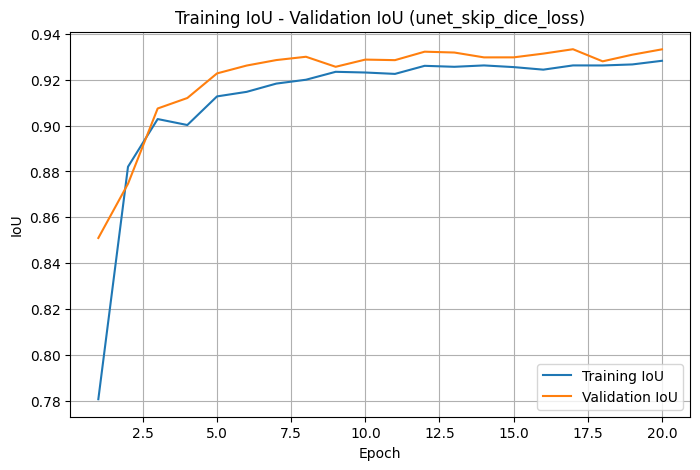

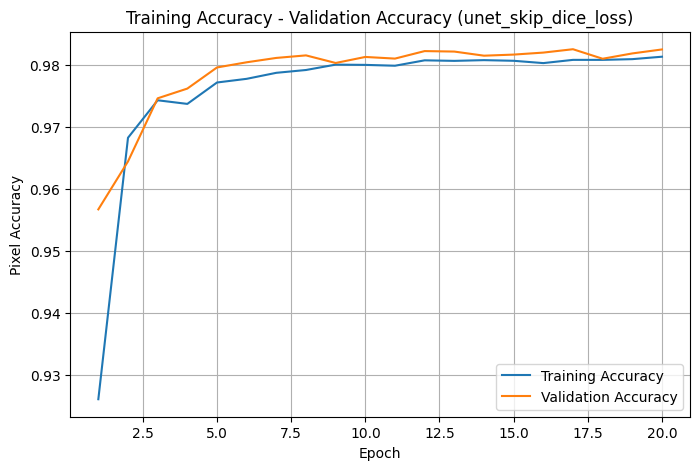

Step 11 completed.
Model: U-Net with skip connections
Loss: Dice Loss
Training time: 196.08 seconds
Best model path: models_q2/best_unet_skip_dice_loss.pth


In [12]:
# ============================================================
# Question 2 - Step 11: Train U-Net WITH Skip Connections
# Loss Function: Dice Loss
# ============================================================

# Create a fresh Lightweight U-Net with skip connections
unet_skip_dice = LightweightUNet(
    in_channels=1,
    out_channels=1,
    base_filters=16,
    use_skip=True
).to(device)

# Loss function: Dice Loss
dice_loss_fn = DiceLoss()

# Train model
unet_skip_dice, history_unet_skip_dice, time_unet_skip_dice = train_segmentation_model(
    model=unet_skip_dice,
    train_loader=train_aug_loader_q2,
    val_loader=val_loader_q2,
    criterion=dice_loss_fn,
    model_name="unet_skip_dice_loss",
    num_epochs=20,
    learning_rate=0.001,
    weight_decay=1e-4,
    patience=5
)

# Plot curves
plot_segmentation_history(
    history=history_unet_skip_dice,
    model_name="unet_skip_dice_loss"
)

print("Step 11 completed.")
print("Model: U-Net with skip connections")
print("Loss: Dice Loss")
print(f"Training time: {time_unet_skip_dice:.2f} seconds")
print("Best model path: models_q2/best_unet_skip_dice_loss.pth")



Training model: unet_skip_bce_dice_loss
Epochs: 20
Learning rate: 0.001
Batch size: 8
Weight decay: 0.0001
EarlyStopping patience: 5
Loss function: BCEDiceLoss

Epoch [1/20]


Loss: 0.4212 | Val Loss: 0.3400
Dice: 0.8495 | Val Dice: 0.9163
IoU:  0.7601 | Val IoU:  0.8463
Acc:  0.9016 | Val Acc:  0.9547
Current LR: 0.00100000
Best model saved.

Epoch [2/20]


Loss: 0.2915 | Val Loss: 0.2480
Dice: 0.9357 | Val Dice: 0.9528
IoU:  0.8808 | Val IoU:  0.9106
Acc:  0.9680 | Val Acc:  0.9760
Current LR: 0.00100000
Best model saved.

Epoch [3/20]


Loss: 0.2126 | Val Loss: 0.1768
Dice: 0.9469 | Val Dice: 0.9559
IoU:  0.9003 | Val IoU:  0.9163
Acc:  0.9737 | Val Acc:  0.9777
Current LR: 0.00100000
Best model saved.

Epoch [4/20]


Loss: 0.1536 | Val Loss: 0.1347
Dice: 0.9510 | Val Dice: 0.9490
IoU:  0.9077 | Val IoU:  0.9041
Acc:  0.9756 | Val Acc:  0.9743
Current LR: 0.00100000
Best model saved.

Epoch [5/20]


...

Loss: 0.0548 | Val Loss: 0.0514
Dice: 0.9612 | Val Dice: 0.9634
IoU:  0.9263 | Val IoU:  0.9302
Acc:  0.9809 | Val Acc:  0.9816
Current LR: 0.00100000
No improvement. EarlyStopping counter: 1/5

Epoch [17/20]


Loss: 0.0546 | Val Loss: 0.0578
Dice: 0.9612 | Val Dice: 0.9592
IoU:  0.9262 | Val IoU:  0.9228
Acc:  0.9807 | Val Acc:  0.9798
Current LR: 0.00100000
No improvement. EarlyStopping counter: 2/5

Epoch [18/20]


Loss: 0.0539 | Val Loss: 0.0516
Dice: 0.9610 | Val Dice: 0.9632
IoU:  0.9260 | Val IoU:  0.9299
Acc:  0.9808 | Val Acc:  0.9816
Current LR: 0.00050000
No improvement. EarlyStopping counter: 3/5

Epoch [19/20]


Loss: 0.0531 | Val Loss: 0.0485
Dice: 0.9614 | Val Dice: 0.9652
IoU:  0.9267 | Val IoU:  0.9336
Acc:  0.9810 | Val Acc:  0.9826
Current LR: 0.00050000
Best model saved.

Epoch [20/20]


Loss: 0.0521 | Val Loss: 0.0481
Dice: 0.9623 | Val Dice: 0.9652
IoU:  0.9284 | Val IoU:  0.9337
Acc:  0.9813 | Val Acc:  0.9827
Current LR: 0.00050000
Best model saved.

Training completed.
Best validation loss: 0.0481
Validation Dice at best loss: 0.9652
Training time: 193.05 seconds
History saved to: outputs_q2/history_unet_skip_bce_dice_loss.csv
Best model saved to: models_q2/best_unet_skip_bce_dice_loss.pth


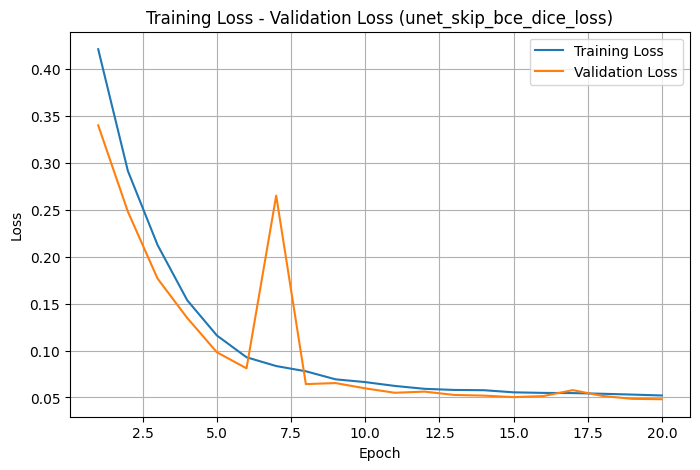

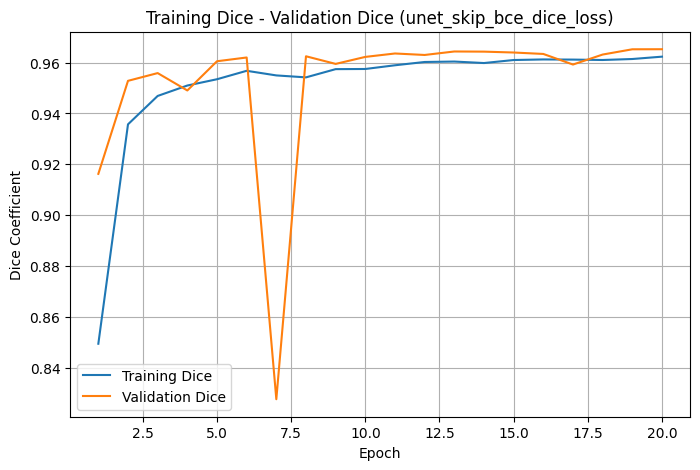

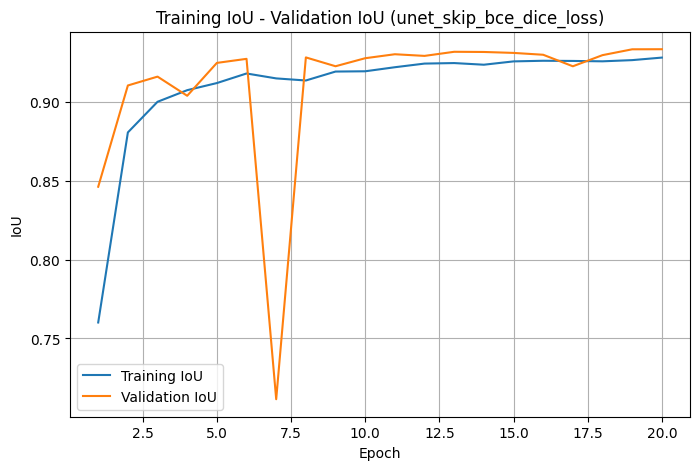

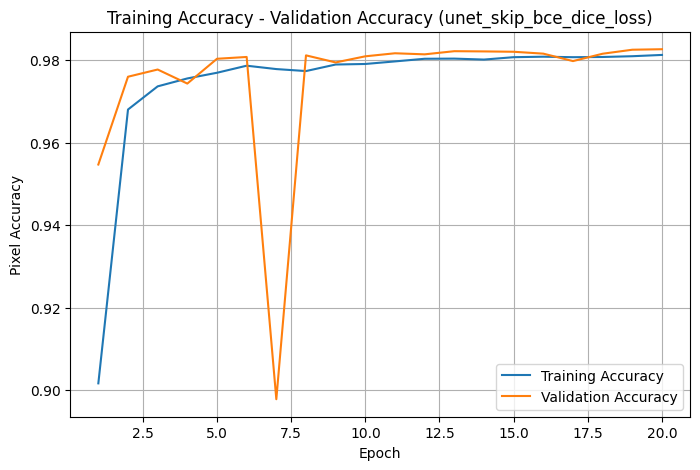

Step 12 completed.
Model: U-Net with skip connections
Loss: BCE + Dice Loss
Training time: 193.05 seconds
Best model path: models_q2/best_unet_skip_bce_dice_loss.pth


In [13]:
# ============================================================
# Question 2 - Step 12: Train U-Net WITH Skip Connections
# Loss Function: BCE + Dice Loss
# ============================================================

# Create a fresh Lightweight U-Net with skip connections
unet_skip_bce_dice = LightweightUNet(
    in_channels=1,
    out_channels=1,
    base_filters=16,
    use_skip=True
).to(device)

# Loss function: BCE + Dice Loss
bce_dice_loss_fn = BCEDiceLoss(
    bce_weight=0.5,
    dice_weight=0.5
)

# Train model
unet_skip_bce_dice, history_unet_skip_bce_dice, time_unet_skip_bce_dice = train_segmentation_model(
    model=unet_skip_bce_dice,
    train_loader=train_aug_loader_q2,
    val_loader=val_loader_q2,
    criterion=bce_dice_loss_fn,
    model_name="unet_skip_bce_dice_loss",
    num_epochs=20,
    learning_rate=0.001,
    weight_decay=1e-4,
    patience=5
)

# Plot curves
plot_segmentation_history(
    history=history_unet_skip_bce_dice,
    model_name="unet_skip_bce_dice_loss"
)

print("Step 12 completed.")
print("Model: U-Net with skip connections")
print("Loss: BCE + Dice Loss")
print(f"Training time: {time_unet_skip_bce_dice:.2f} seconds")
print("Best model path: models_q2/best_unet_skip_bce_dice_loss.pth")


,Model,Loss Function,Epochs Trained,Best Val Loss,Best Val Dice,Best Val IoU,Best Val Accuracy,Final Val Dice,Training Time (sec)
0,U-Net with Skip,Dice Loss,20,0.036695,0.965000,0.933211,0.982469,0.965000,196.082617
1,U-Net with Skip,BCE + Dice Loss,20,0.048106,0.965247,0.933671,0.982673,0.965247,193.049401


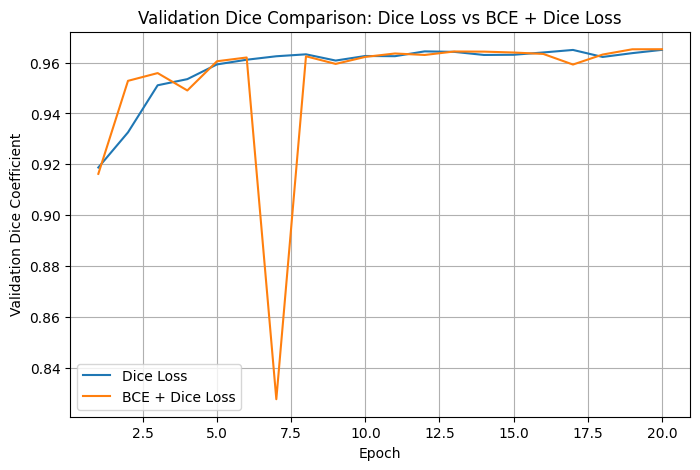

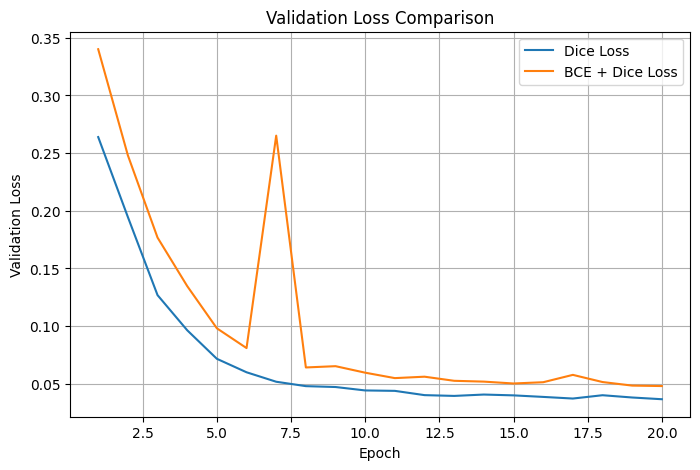

Step 13 completed.
Comparison table saved to:
outputs_q2/loss_function_comparison_unet_skip.csv
Figures saved to:
outputs_q2/val_dice_loss_function_comparison.png
outputs_q2/val_loss_function_comparison.png

Conclusion:
BCE + Dice Loss achieved slightly better or equal validation Dice.
We will use BCE + Dice Loss for the next comparison with the no-skip U-Net.


In [14]:
# ============================================================
# Question 2 - Step 13: Compare Dice Loss vs BCE + Dice Loss
# For U-Net WITH Skip Connections
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Load training histories
# ------------------------------------------------------------

history_dice_df = pd.read_csv("outputs_q2/history_unet_skip_dice_loss.csv")
history_bce_dice_df = pd.read_csv("outputs_q2/history_unet_skip_bce_dice_loss.csv")

# ------------------------------------------------------------
# 2. Extract best values
# For Dice-based metrics, higher is better.
# For validation loss, lower is better.
# ------------------------------------------------------------

dice_best_val_loss = history_dice_df["val_loss"].min()
dice_best_val_dice = history_dice_df["val_dice_coef"].max()
dice_best_val_iou = history_dice_df["val_iou"].max()
dice_best_val_acc = history_dice_df["val_accuracy"].max()
dice_final_val_dice = history_dice_df["val_dice_coef"].iloc[-1]
dice_epochs = len(history_dice_df)

bce_dice_best_val_loss = history_bce_dice_df["val_loss"].min()
bce_dice_best_val_dice = history_bce_dice_df["val_dice_coef"].max()
bce_dice_best_val_iou = history_bce_dice_df["val_iou"].max()
bce_dice_best_val_acc = history_bce_dice_df["val_accuracy"].max()
bce_dice_final_val_dice = history_bce_dice_df["val_dice_coef"].iloc[-1]
bce_dice_epochs = len(history_bce_dice_df)

# Training times from your runs
time_unet_skip_dice_value = time_unet_skip_dice
time_unet_skip_bce_dice_value = time_unet_skip_bce_dice

loss_comparison_df = pd.DataFrame([
    {
        "Model": "U-Net with Skip",
        "Loss Function": "Dice Loss",
        "Epochs Trained": dice_epochs,
        "Best Val Loss": dice_best_val_loss,
        "Best Val Dice": dice_best_val_dice,
        "Best Val IoU": dice_best_val_iou,
        "Best Val Accuracy": dice_best_val_acc,
        "Final Val Dice": dice_final_val_dice,
        "Training Time (sec)": time_unet_skip_dice_value
    },
    {
        "Model": "U-Net with Skip",
        "Loss Function": "BCE + Dice Loss",
        "Epochs Trained": bce_dice_epochs,
        "Best Val Loss": bce_dice_best_val_loss,
        "Best Val Dice": bce_dice_best_val_dice,
        "Best Val IoU": bce_dice_best_val_iou,
        "Best Val Accuracy": bce_dice_best_val_acc,
        "Final Val Dice": bce_dice_final_val_dice,
        "Training Time (sec)": time_unet_skip_bce_dice_value
    }
])

display(loss_comparison_df)

loss_comparison_df.to_csv(
    "outputs_q2/loss_function_comparison_unet_skip.csv",
    index=False
)

# ------------------------------------------------------------
# 3. Plot validation Dice comparison
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(history_dice_df) + 1),
    history_dice_df["val_dice_coef"],
    label="Dice Loss"
)
plt.plot(
    range(1, len(history_bce_dice_df) + 1),
    history_bce_dice_df["val_dice_coef"],
    label="BCE + Dice Loss"
)
plt.xlabel("Epoch")
plt.ylabel("Validation Dice Coefficient")
plt.title("Validation Dice Comparison: Dice Loss vs BCE + Dice Loss")
plt.legend()
plt.grid(True)
plt.savefig("outputs_q2/val_dice_loss_function_comparison.png", dpi=300)
plt.show()

# ------------------------------------------------------------
# 4. Plot validation loss comparison
# Note: loss values are not directly identical because the loss definitions differ.
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(history_dice_df) + 1),
    history_dice_df["val_loss"],
    label="Dice Loss"
)
plt.plot(
    range(1, len(history_bce_dice_df) + 1),
    history_bce_dice_df["val_loss"],
    label="BCE + Dice Loss"
)
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss Comparison")
plt.legend()
plt.grid(True)
plt.savefig("outputs_q2/val_loss_function_comparison.png", dpi=300)
plt.show()

print("Step 13 completed.")
print("Comparison table saved to:")
print("outputs_q2/loss_function_comparison_unet_skip.csv")
print("Figures saved to:")
print("outputs_q2/val_dice_loss_function_comparison.png")
print("outputs_q2/val_loss_function_comparison.png")

print("\nConclusion:")
if bce_dice_best_val_dice >= dice_best_val_dice:
    print("BCE + Dice Loss achieved slightly better or equal validation Dice.")
    print("We will use BCE + Dice Loss for the next comparison with the no-skip U-Net.")
else:
    print("Dice Loss achieved better validation Dice.")
    print("We will use Dice Loss for the next comparison with the no-skip U-Net.")



Training model: unet_no_skip_bce_dice_loss
Epochs: 20
Learning rate: 0.001
Batch size: 8
Weight decay: 0.0001
EarlyStopping patience: 5
Loss function: BCEDiceLoss

Epoch [1/20]


Loss: 0.3637 | Val Loss: 0.2494
Dice: 0.8337 | Val Dice: 0.9060
IoU:  0.7392 | Val IoU:  0.8293
Acc:  0.9252 | Val Acc:  0.9501
Current LR: 0.00100000
Best model saved.

Epoch [2/20]


Loss: 0.2134 | Val Loss: 0.1612
Dice: 0.9116 | Val Dice: 0.9271
IoU:  0.8394 | Val IoU:  0.8647
Acc:  0.9564 | Val Acc:  0.9616
Current LR: 0.00100000
Best model saved.

Epoch [3/20]


Loss: 0.1465 | Val Loss: 0.1986
Dice: 0.9275 | Val Dice: 0.8726
IoU:  0.8660 | Val IoU:  0.7753
Acc:  0.9643 | Val Acc:  0.9273
Current LR: 0.00100000
No improvement. EarlyStopping counter: 1/5

Epoch [4/20]


Loss: 0.1170 | Val Loss: 0.1069
Dice: 0.9314 | Val Dice: 0.9379
IoU:  0.8727 | Val IoU:  0.8841
Acc:  0.9662 | Val Acc:  0.9694
Current LR: 0.00100000
Best model saved.

Epoch [5/20]


...

Loss: 0.0600 | Val Loss: 0.0612
Dice: 0.9544 | Val Dice: 0.9548
IoU:  0.9135 | Val IoU:  0.9142
Acc:  0.9776 | Val Acc:  0.9770
Current LR: 0.00100000
No improvement. EarlyStopping counter: 1/5

Epoch [17/20]


Loss: 0.0606 | Val Loss: 0.0619
Dice: 0.9538 | Val Dice: 0.9525
IoU:  0.9124 | Val IoU:  0.9100
Acc:  0.9772 | Val Acc:  0.9759
Current LR: 0.00100000
No improvement. EarlyStopping counter: 2/5

Epoch [18/20]


Loss: 0.0590 | Val Loss: 0.0565
Dice: 0.9551 | Val Dice: 0.9572
IoU:  0.9147 | Val IoU:  0.9187
Acc:  0.9777 | Val Acc:  0.9785
Current LR: 0.00100000
Best model saved.

Epoch [19/20]


Loss: 0.0568 | Val Loss: 0.0582
Dice: 0.9566 | Val Dice: 0.9562
IoU:  0.9175 | Val IoU:  0.9170
Acc:  0.9785 | Val Acc:  0.9779
Current LR: 0.00100000
No improvement. EarlyStopping counter: 1/5

Epoch [20/20]


Loss: 0.0580 | Val Loss: 0.0601
Dice: 0.9555 | Val Dice: 0.9541
IoU:  0.9155 | Val IoU:  0.9131
Acc:  0.9780 | Val Acc:  0.9772
Current LR: 0.00100000
No improvement. EarlyStopping counter: 2/5

Training completed.
Best validation loss: 0.0565
Validation Dice at best loss: 0.9572
Training time: 191.97 seconds
History saved to: outputs_q2/history_unet_no_skip_bce_dice_loss.csv
Best model saved to: models_q2/best_unet_no_skip_bce_dice_loss.pth


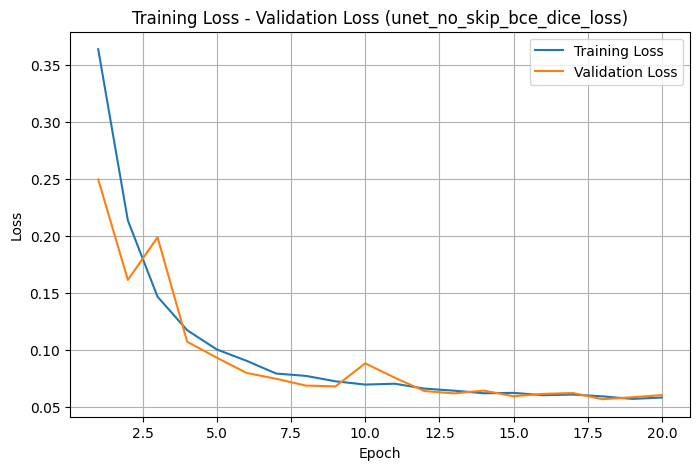

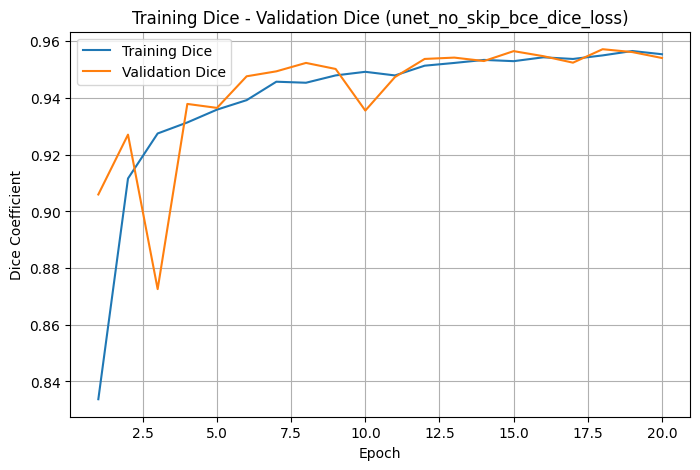

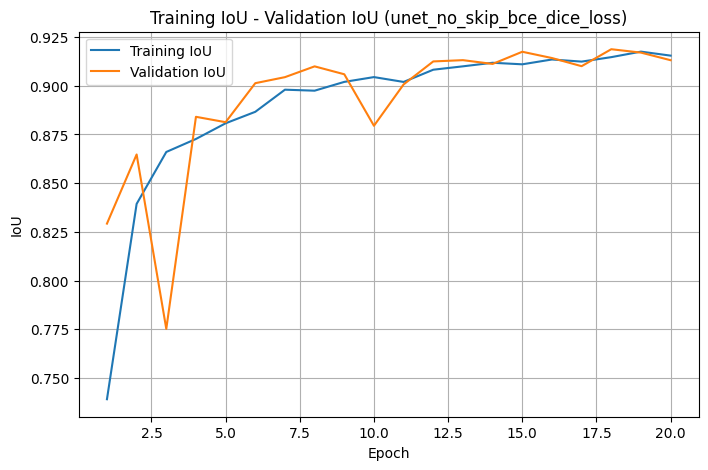

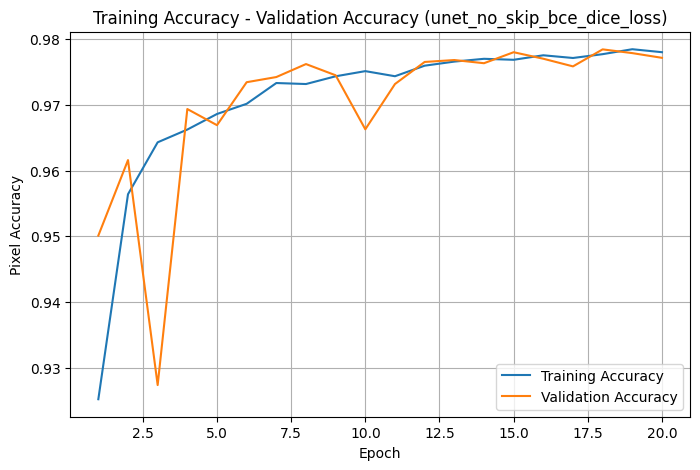

Step 14 completed.
Model: U-Net without skip connections
Loss: BCE + Dice Loss
Training time: 191.97 seconds
Best model path: models_q2/best_unet_no_skip_bce_dice_loss.pth


In [15]:
# ============================================================
# Question 2 - Step 14: Train U-Net WITHOUT Skip Connections
# Loss Function: BCE + Dice Loss
# ============================================================

# Create a fresh Lightweight U-Net without skip connections
unet_no_skip_bce_dice = LightweightUNet(
    in_channels=1,
    out_channels=1,
    base_filters=16,
    use_skip=False
).to(device)

# Loss function: BCE + Dice Loss
bce_dice_loss_fn = BCEDiceLoss(
    bce_weight=0.5,
    dice_weight=0.5
)

# Train model
unet_no_skip_bce_dice, history_unet_no_skip_bce_dice, time_unet_no_skip_bce_dice = train_segmentation_model(
    model=unet_no_skip_bce_dice,
    train_loader=train_aug_loader_q2,
    val_loader=val_loader_q2,
    criterion=bce_dice_loss_fn,
    model_name="unet_no_skip_bce_dice_loss",
    num_epochs=20,
    learning_rate=0.001,
    weight_decay=1e-4,
    patience=5
)

# Plot curves
plot_segmentation_history(
    history=history_unet_no_skip_bce_dice,
    model_name="unet_no_skip_bce_dice_loss"
)

print("Step 14 completed.")
print("Model: U-Net without skip connections")
print("Loss: BCE + Dice Loss")
print(f"Training time: {time_unet_no_skip_bce_dice:.2f} seconds")
print("Best model path: models_q2/best_unet_no_skip_bce_dice_loss.pth")


,Model,Parameters,Epochs Trained,Best Val Loss,Best Val Dice,Best Val IoU,Best Val Accuracy,Training Time (sec)
0,U-Net with Skip Connections,1942289,20,0.048106,0.965247,0.933671,0.982673,193.049401
1,U-Net without Skip Connections,1746449,20,0.056485,0.957231,0.918737,0.978464,191.966517


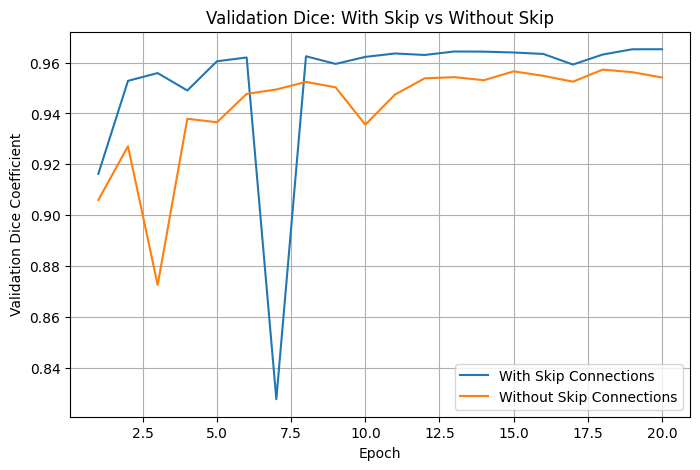

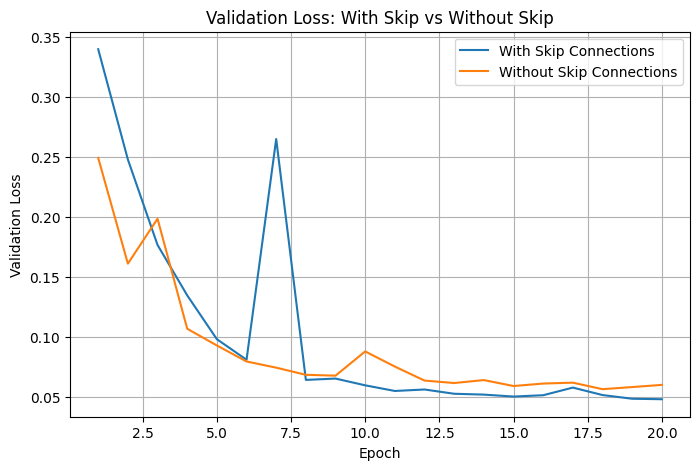

Step 15 completed.
Comparison table saved to:
outputs_q2/skip_vs_no_skip_comparison.csv
Figures saved to:
outputs_q2/val_dice_skip_vs_no_skip.png
outputs_q2/val_loss_skip_vs_no_skip.png

Conclusion:
U-Net with skip connections achieved better validation Dice.
Therefore, the final selected model is U-Net with skip connections and BCE + Dice Loss.


In [16]:
# ============================================================
# Question 2 - Step 15: Compare U-Net WITH Skip vs WITHOUT Skip
# Both trained with BCE + Dice Loss
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Load histories
# ------------------------------------------------------------

history_skip_df = pd.read_csv("outputs_q2/history_unet_skip_bce_dice_loss.csv")
history_no_skip_df = pd.read_csv("outputs_q2/history_unet_no_skip_bce_dice_loss.csv")

# ------------------------------------------------------------
# 2. Extract best values
# ------------------------------------------------------------

skip_best_val_loss = history_skip_df["val_loss"].min()
skip_best_val_dice = history_skip_df["val_dice_coef"].max()
skip_best_val_iou = history_skip_df["val_iou"].max()
skip_best_val_acc = history_skip_df["val_accuracy"].max()
skip_epochs = len(history_skip_df)

no_skip_best_val_loss = history_no_skip_df["val_loss"].min()
no_skip_best_val_dice = history_no_skip_df["val_dice_coef"].max()
no_skip_best_val_iou = history_no_skip_df["val_iou"].max()
no_skip_best_val_acc = history_no_skip_df["val_accuracy"].max()
no_skip_epochs = len(history_no_skip_df)

# These variables were created in Step 8 and Step 14.
# If Colab lost them, manually replace the values:
# skip_total = 1_942_289
# noskip_total = 1_746_449
# time_unet_skip_bce_dice = 193.049401
# time_unet_no_skip_bce_dice = 191.97

comparison_skip_df = pd.DataFrame([
    {
        "Model": "U-Net with Skip Connections",
        "Parameters": skip_total,
        "Epochs Trained": skip_epochs,
        "Best Val Loss": skip_best_val_loss,
        "Best Val Dice": skip_best_val_dice,
        "Best Val IoU": skip_best_val_iou,
        "Best Val Accuracy": skip_best_val_acc,
        "Training Time (sec)": time_unet_skip_bce_dice
    },
    {
        "Model": "U-Net without Skip Connections",
        "Parameters": noskip_total,
        "Epochs Trained": no_skip_epochs,
        "Best Val Loss": no_skip_best_val_loss,
        "Best Val Dice": no_skip_best_val_dice,
        "Best Val IoU": no_skip_best_val_iou,
        "Best Val Accuracy": no_skip_best_val_acc,
        "Training Time (sec)": time_unet_no_skip_bce_dice
    }
])

display(comparison_skip_df)

comparison_skip_df.to_csv(
    "outputs_q2/skip_vs_no_skip_comparison.csv",
    index=False
)

# ------------------------------------------------------------
# 3. Plot validation Dice comparison
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(history_skip_df) + 1),
    history_skip_df["val_dice_coef"],
    label="With Skip Connections"
)
plt.plot(
    range(1, len(history_no_skip_df) + 1),
    history_no_skip_df["val_dice_coef"],
    label="Without Skip Connections"
)
plt.xlabel("Epoch")
plt.ylabel("Validation Dice Coefficient")
plt.title("Validation Dice: With Skip vs Without Skip")
plt.legend()
plt.grid(True)
plt.savefig("outputs_q2/val_dice_skip_vs_no_skip.png", dpi=300)
plt.show()

# ------------------------------------------------------------
# 4. Plot validation loss comparison
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(history_skip_df) + 1),
    history_skip_df["val_loss"],
    label="With Skip Connections"
)
plt.plot(
    range(1, len(history_no_skip_df) + 1),
    history_no_skip_df["val_loss"],
    label="Without Skip Connections"
)
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss: With Skip vs Without Skip")
plt.legend()
plt.grid(True)
plt.savefig("outputs_q2/val_loss_skip_vs_no_skip.png", dpi=300)
plt.show()

print("Step 15 completed.")
print("Comparison table saved to:")
print("outputs_q2/skip_vs_no_skip_comparison.csv")
print("Figures saved to:")
print("outputs_q2/val_dice_skip_vs_no_skip.png")
print("outputs_q2/val_loss_skip_vs_no_skip.png")

print("\nConclusion:")
if skip_best_val_dice >= no_skip_best_val_dice:
    print("U-Net with skip connections achieved better validation Dice.")
    print("Therefore, the final selected model is U-Net with skip connections and BCE + Dice Loss.")
else:
    print("U-Net without skip connections achieved better validation Dice.")
    print("Therefore, the final selected model is U-Net without skip connections and BCE + Dice Loss.")


Final Test Results - Best U-Net
--------------------------------
Test Loss:     0.0581
Test Dice:     0.9575
Test IoU:      0.9206
Test Accuracy: 0.9793


,Model,Loss Function,Test Loss,Test Dice,Test IoU,Test Accuracy
0,U-Net with Skip Connections,BCE + Dice Loss,0.058083,0.957483,0.92059,0.9793


,Sample,Dice Score,IoU Score
0,1,0.829477,0.708638
1,2,0.964348,0.931151
2,3,0.973762,0.948865
3,4,0.869934,0.769808
4,5,0.967877,0.937754
5,6,0.983191,0.966938
6,7,0.976306,0.953709
7,8,0.971027,0.943686
8,9,0.975921,0.952975
9,10,0.970282,0.942280


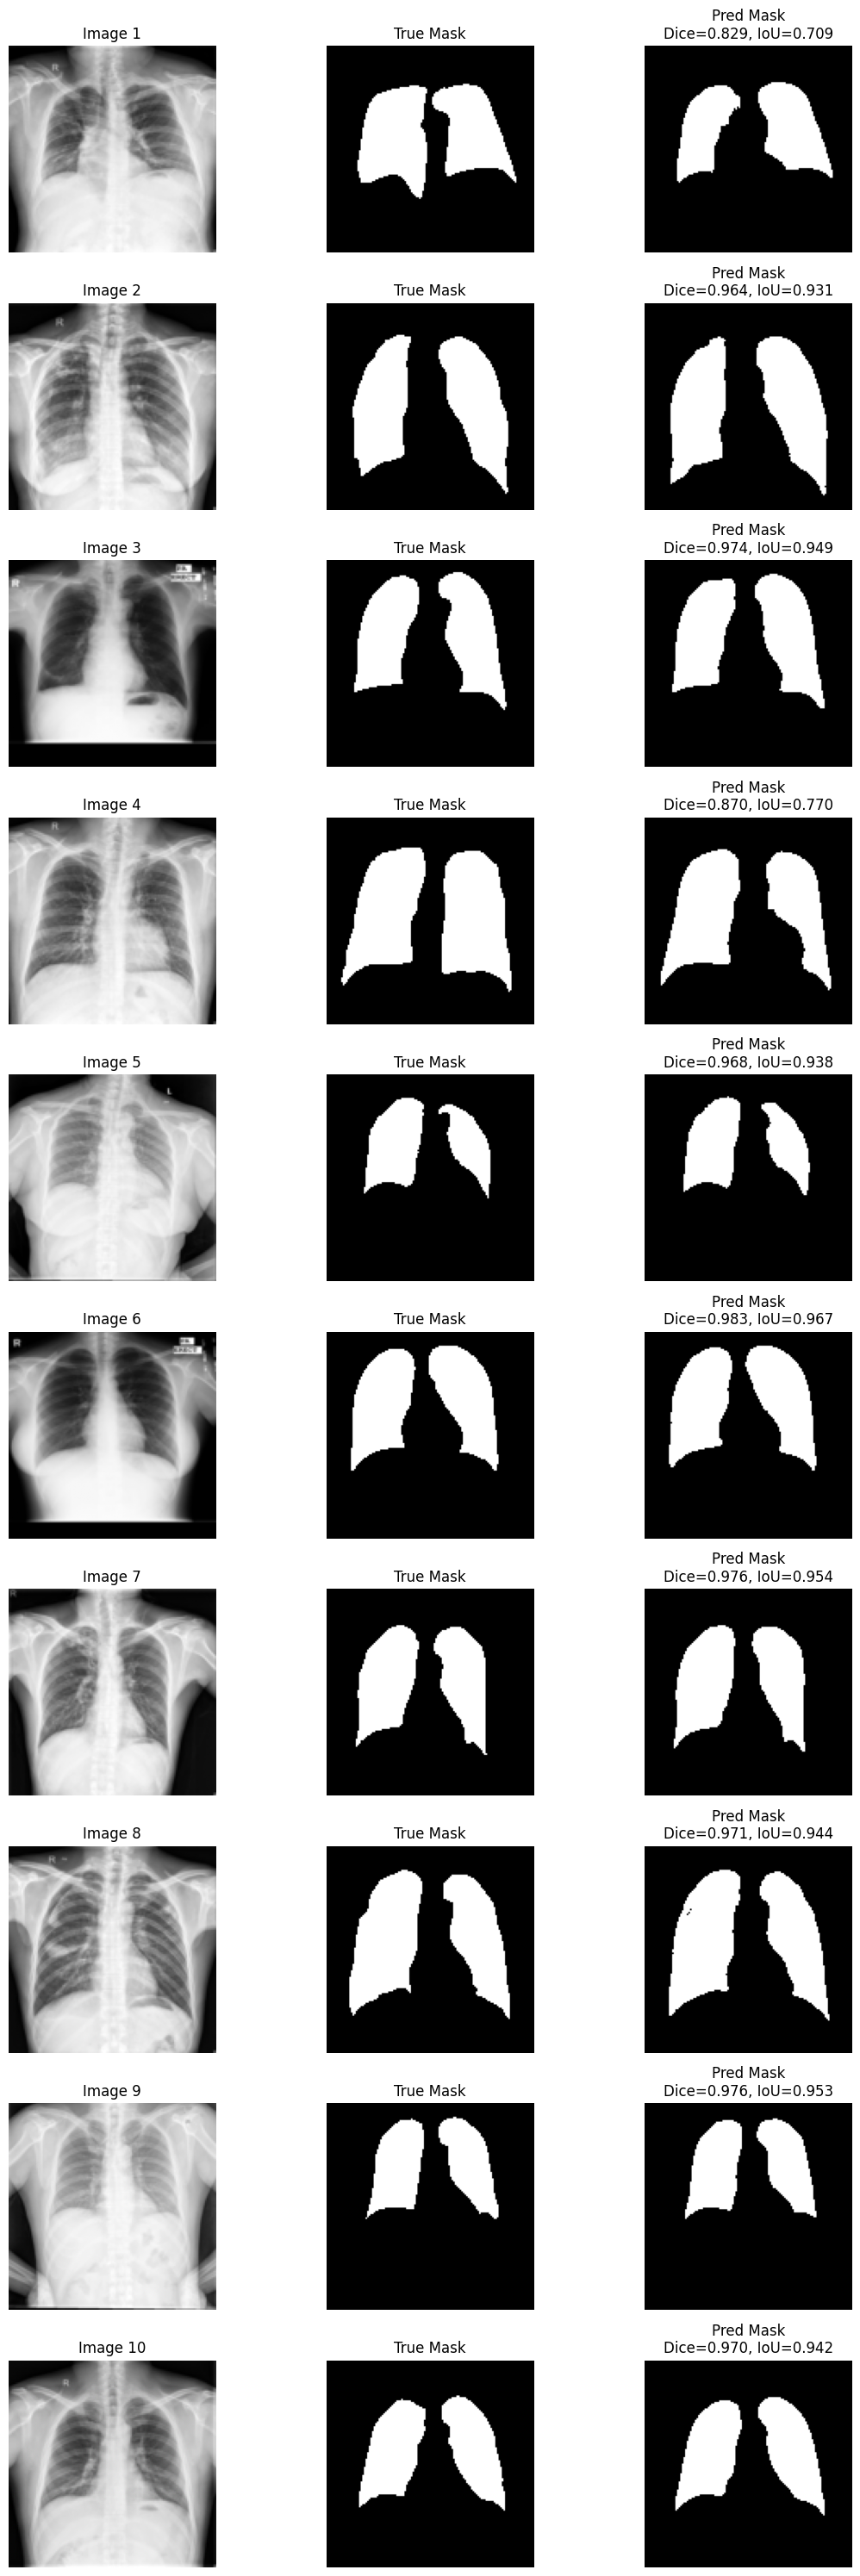


Weakest sample among the displayed 10 samples:
Sample number: 1
Dice Score: 0.8295
IoU Score: 0.7086

Saved outputs:
outputs_q2/final_test_results_best_unet.csv
outputs_q2/test_10_sample_prediction_metrics.csv
outputs_q2/test_10_predictions_best_unet.png

Step 16 completed.


In [17]:
# ============================================================
# Question 2 - Step 16: Final Test Evaluation of Best U-Net
# Best model: U-Net WITH skip connections + BCE + Dice Loss
# ============================================================

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Load the best selected model
# ------------------------------------------------------------

best_unet_model = LightweightUNet(
    in_channels=1,
    out_channels=1,
    base_filters=16,
    use_skip=True
).to(device)

best_unet_model.load_state_dict(
    torch.load(
        "models_q2/best_unet_skip_bce_dice_loss.pth",
        map_location=device
    )
)

best_unet_model.eval()

# Loss function used for the selected model
final_criterion = BCEDiceLoss(
    bce_weight=0.5,
    dice_weight=0.5
)

# ------------------------------------------------------------
# 2. Evaluate on test set
# ------------------------------------------------------------

test_loss, test_dice, test_iou, test_acc = evaluate_segmentation_model(
    model=best_unet_model,
    data_loader=test_loader_q2,
    criterion=final_criterion,
    device=device,
    desc="Testing best U-Net"
)

print("Final Test Results - Best U-Net")
print("--------------------------------")
print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Dice:     {test_dice:.4f}")
print(f"Test IoU:      {test_iou:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

test_results_df = pd.DataFrame([
    {
        "Model": "U-Net with Skip Connections",
        "Loss Function": "BCE + Dice Loss",
        "Test Loss": test_loss,
        "Test Dice": test_dice,
        "Test IoU": test_iou,
        "Test Accuracy": test_acc
    }
])

display(test_results_df)

test_results_df.to_csv(
    "outputs_q2/final_test_results_best_unet.csv",
    index=False
)

# ------------------------------------------------------------
# 3. Collect 10 test predictions
# ------------------------------------------------------------

num_samples_to_show = 10

sample_images = []
sample_true_masks = []
sample_pred_masks = []
sample_pred_probs = []
sample_dice_scores = []
sample_iou_scores = []

best_unet_model.eval()

with torch.no_grad():
    for images, masks in test_loader_q2:
        images = images.to(device)
        masks = masks.to(device)

        outputs = best_unet_model(images)
        preds = (outputs >= 0.5).float()

        for i in range(images.size(0)):
            img_i = images[i:i+1]
            mask_i = masks[i:i+1]
            output_i = outputs[i:i+1]
            pred_i = preds[i:i+1]

            dice_i = dice_coefficient(output_i, mask_i).item()
            iou_i = iou_score(output_i, mask_i).item()

            sample_images.append(img_i.cpu().squeeze().numpy())
            sample_true_masks.append(mask_i.cpu().squeeze().numpy())
            sample_pred_masks.append(pred_i.cpu().squeeze().numpy())
            sample_pred_probs.append(output_i.cpu().squeeze().numpy())
            sample_dice_scores.append(dice_i)
            sample_iou_scores.append(iou_i)

            if len(sample_images) >= num_samples_to_show:
                break

        if len(sample_images) >= num_samples_to_show:
            break

# ------------------------------------------------------------
# 4. Save table of per-sample metrics
# ------------------------------------------------------------

sample_metrics_df = pd.DataFrame({
    "Sample": list(range(1, num_samples_to_show + 1)),
    "Dice Score": sample_dice_scores,
    "IoU Score": sample_iou_scores
})

display(sample_metrics_df)

sample_metrics_df.to_csv(
    "outputs_q2/test_10_sample_prediction_metrics.csv",
    index=False
)

# ------------------------------------------------------------
# 5. Plot 10 test samples:
# original image, ground-truth mask, predicted mask
# ------------------------------------------------------------

plt.figure(figsize=(12, 30))

for i in range(num_samples_to_show):
    # Original image
    plt.subplot(num_samples_to_show, 3, 3 * i + 1)
    plt.imshow(sample_images[i], cmap="gray")
    plt.title(f"Image {i+1}")
    plt.axis("off")

    # Ground-truth mask
    plt.subplot(num_samples_to_show, 3, 3 * i + 2)
    plt.imshow(sample_true_masks[i], cmap="gray")
    plt.title("True Mask")
    plt.axis("off")

    # Predicted mask
    plt.subplot(num_samples_to_show, 3, 3 * i + 3)
    plt.imshow(sample_pred_masks[i], cmap="gray")
    plt.title(
        f"Pred Mask\nDice={sample_dice_scores[i]:.3f}, IoU={sample_iou_scores[i]:.3f}"
    )
    plt.axis("off")

plt.tight_layout()
plt.savefig("outputs_q2/test_10_predictions_best_unet.png", dpi=300)
plt.show()

# ------------------------------------------------------------
# 6. Identify weakest samples among these 10
# ------------------------------------------------------------

weakest_index = int(np.argmin(sample_dice_scores))

print("\nWeakest sample among the displayed 10 samples:")
print(f"Sample number: {weakest_index + 1}")
print(f"Dice Score: {sample_dice_scores[weakest_index]:.4f}")
print(f"IoU Score: {sample_iou_scores[weakest_index]:.4f}")

print("\nSaved outputs:")
print("outputs_q2/final_test_results_best_unet.csv")
print("outputs_q2/test_10_sample_prediction_metrics.csv")
print("outputs_q2/test_10_predictions_best_unet.png")

print("\nStep 16 completed.")

Batch-size-16 DataLoaders are ready.
Train batches: 36
Validation batches: 5
Test batches: 5

Training model: unet_skip_bce_dice_loss_bs16
Epochs: 20
Learning rate: 0.001
Batch size: 16
Weight decay: 0.0001
EarlyStopping patience: 5
Loss function: BCEDiceLoss

Epoch [1/20]


Loss: 0.4421 | Val Loss: 0.4197
Dice: 0.8162 | Val Dice: 0.8316
IoU:  0.7186 | Val IoU:  0.7165
Acc:  0.8977 | Val Acc:  0.9026
Current LR: 0.00100000
Best model saved.

Epoch [2/20]


Loss: 0.3082 | Val Loss: 0.2810
Dice: 0.9294 | Val Dice: 0.9301
IoU:  0.8696 | Val IoU:  0.8700
Acc:  0.9646 | Val Acc:  0.9631
Current LR: 0.00100000
Best model saved.

Epoch [3/20]


Loss: 0.2355 | Val Loss: 0.2076
Dice: 0.9413 | Val Dice: 0.9422
IoU:  0.8904 | Val IoU:  0.8914
Acc:  0.9708 | Val Acc:  0.9701
Current LR: 0.00100000
Best model saved.

Epoch [4/20]


Loss: 0.1861 | Val Loss: 0.1625
Dice: 0.9435 | Val Dice: 0.9484
IoU:  0.8945 | Val IoU:  0.9027
Acc:  0.9719 | Val Acc:  0.9735
Current LR: 0.00100000
Best model saved.

Epoch [5/20]


...

Loss: 0.0601 | Val Loss: 0.0585
Dice: 0.9602 | Val Dice: 0.9612
IoU:  0.9244 | Val IoU:  0.9262
Acc:  0.9803 | Val Acc:  0.9804
Current LR: 0.00100000
Best model saved.

Epoch [17/20]


Loss: 0.0597 | Val Loss: 0.0579
Dice: 0.9597 | Val Dice: 0.9604
IoU:  0.9235 | Val IoU:  0.9249
Acc:  0.9801 | Val Acc:  0.9803
Current LR: 0.00100000
Best model saved.

Epoch [18/20]


Loss: 0.0585 | Val Loss: 0.0564
Dice: 0.9604 | Val Dice: 0.9617
IoU:  0.9250 | Val IoU:  0.9273
Acc:  0.9804 | Val Acc:  0.9810
Current LR: 0.00100000
Best model saved.

Epoch [19/20]


Loss: 0.0565 | Val Loss: 0.0557
Dice: 0.9612 | Val Dice: 0.9618
IoU:  0.9263 | Val IoU:  0.9275
Acc:  0.9807 | Val Acc:  0.9810
Current LR: 0.00100000
Best model saved.

Epoch [20/20]


Loss: 0.0588 | Val Loss: 0.0572
Dice: 0.9591 | Val Dice: 0.9615
IoU:  0.9225 | Val IoU:  0.9268
Acc:  0.9798 | Val Acc:  0.9807
Current LR: 0.00100000
No improvement. EarlyStopping counter: 1/5

Training completed.
Best validation loss: 0.0557
Validation Dice at best loss: 0.9618
Training time: 202.69 seconds
History saved to: outputs_q2/history_unet_skip_bce_dice_loss_bs16.csv
Best model saved to: models_q2/best_unet_skip_bce_dice_loss_bs16.pth


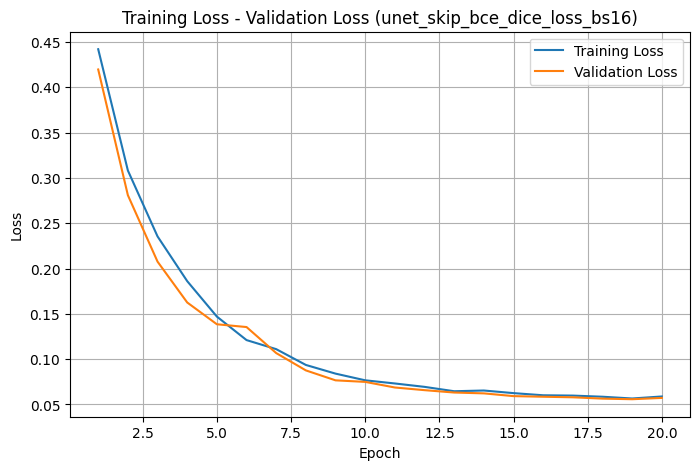

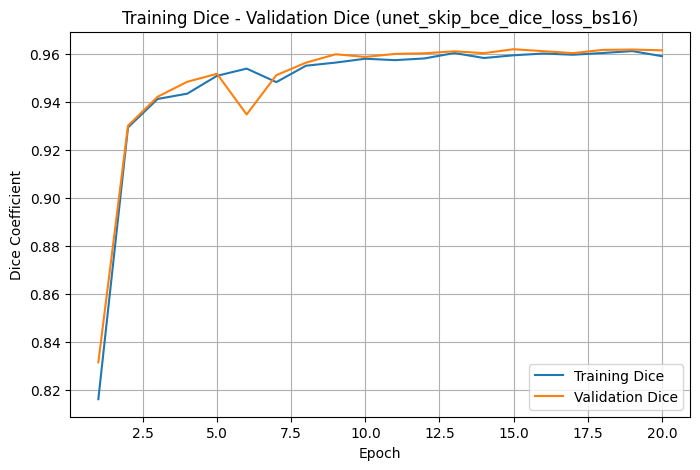

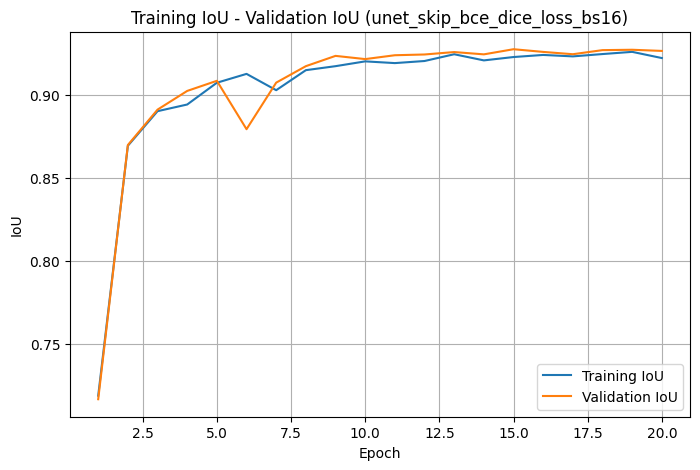

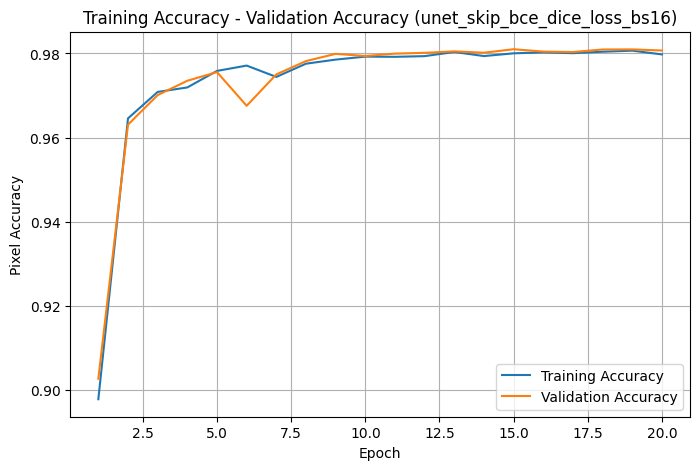

,Batch Size,Best Val Loss,Best Val Dice,Best Val IoU,Best Val Accuracy,Epochs Trained,Training Time (sec)
0,8,0.048106,0.965247,0.933671,0.982673,20,193.049401
1,16,0.055738,0.961978,0.927871,0.981016,20,202.692809


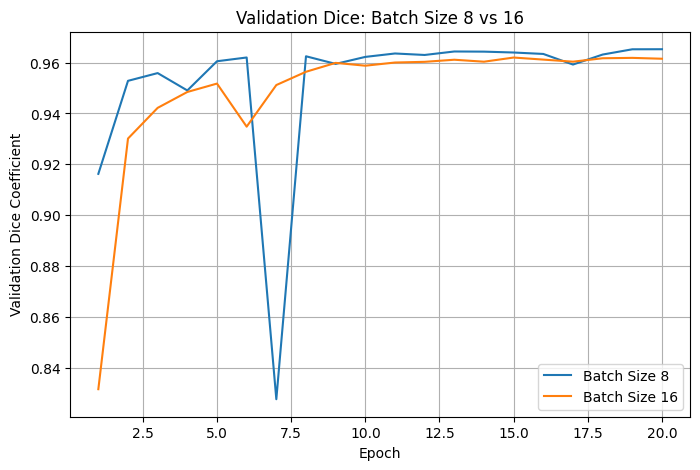

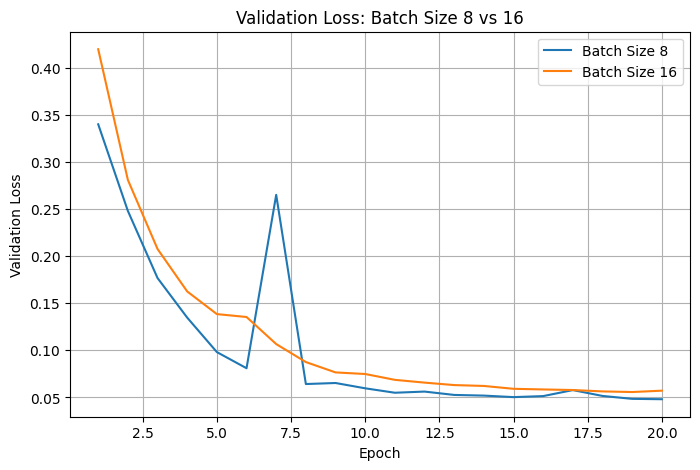

Step 17 completed.
Comparison table saved to:
outputs_q2/batch_size_comparison.csv
Figures saved to:
outputs_q2/val_dice_batch_size_comparison.png
outputs_q2/val_loss_batch_size_comparison.png


In [18]:
# ============================================================
# Question 2 - Step 17: Batch Size Comparison
# Compare Batch Size 8 vs Batch Size 16
# Model: U-Net with Skip Connections + BCE + Dice Loss
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

# ------------------------------------------------------------
# 1. Current best model was trained with batch size 8.
# Now we train the same setting with batch size 16.
# ------------------------------------------------------------

BATCH_SIZE_COMPARE = 16

train_aug_loader_q2_bs16 = DataLoader(
    train_aug_dataset_q2,
    batch_size=BATCH_SIZE_COMPARE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader_q2_bs16 = DataLoader(
    val_dataset_q2_noaug,
    batch_size=BATCH_SIZE_COMPARE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader_q2_bs16 = DataLoader(
    test_dataset_q2_noaug,
    batch_size=BATCH_SIZE_COMPARE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Batch-size-16 DataLoaders are ready.")
print("Train batches:", len(train_aug_loader_q2_bs16))
print("Validation batches:", len(val_loader_q2_bs16))
print("Test batches:", len(test_loader_q2_bs16))


# ------------------------------------------------------------
# 2. Temporarily update BATCH_SIZE_Q2 for correct printing
# inside train_segmentation_model.
# ------------------------------------------------------------

old_batch_size_q2 = BATCH_SIZE_Q2
BATCH_SIZE_Q2 = BATCH_SIZE_COMPARE


# ------------------------------------------------------------
# 3. Train U-Net with skip connections using batch size 16
# ------------------------------------------------------------

unet_skip_bce_dice_bs16 = LightweightUNet(
    in_channels=1,
    out_channels=1,
    base_filters=16,
    use_skip=True
).to(device)

bce_dice_loss_fn = BCEDiceLoss(
    bce_weight=0.5,
    dice_weight=0.5
)

unet_skip_bce_dice_bs16, history_unet_skip_bce_dice_bs16, time_unet_skip_bce_dice_bs16 = train_segmentation_model(
    model=unet_skip_bce_dice_bs16,
    train_loader=train_aug_loader_q2_bs16,
    val_loader=val_loader_q2_bs16,
    criterion=bce_dice_loss_fn,
    model_name="unet_skip_bce_dice_loss_bs16",
    num_epochs=20,
    learning_rate=0.001,
    weight_decay=1e-4,
    patience=5
)

plot_segmentation_history(
    history=history_unet_skip_bce_dice_bs16,
    model_name="unet_skip_bce_dice_loss_bs16"
)

# Restore original batch size variable
BATCH_SIZE_Q2 = old_batch_size_q2


# ------------------------------------------------------------
# 4. Compare batch size 8 vs batch size 16
# ------------------------------------------------------------

history_bs8_df = pd.read_csv("outputs_q2/history_unet_skip_bce_dice_loss.csv")
history_bs16_df = pd.read_csv("outputs_q2/history_unet_skip_bce_dice_loss_bs16.csv")

batch_comparison_df = pd.DataFrame([
    {
        "Batch Size": 8,
        "Best Val Loss": history_bs8_df["val_loss"].min(),
        "Best Val Dice": history_bs8_df["val_dice_coef"].max(),
        "Best Val IoU": history_bs8_df["val_iou"].max(),
        "Best Val Accuracy": history_bs8_df["val_accuracy"].max(),
        "Epochs Trained": len(history_bs8_df),
        "Training Time (sec)": time_unet_skip_bce_dice
    },
    {
        "Batch Size": 16,
        "Best Val Loss": history_bs16_df["val_loss"].min(),
        "Best Val Dice": history_bs16_df["val_dice_coef"].max(),
        "Best Val IoU": history_bs16_df["val_iou"].max(),
        "Best Val Accuracy": history_bs16_df["val_accuracy"].max(),
        "Epochs Trained": len(history_bs16_df),
        "Training Time (sec)": time_unet_skip_bce_dice_bs16
    }
])

display(batch_comparison_df)

batch_comparison_df.to_csv(
    "outputs_q2/batch_size_comparison.csv",
    index=False
)


# ------------------------------------------------------------
# 5. Plot validation Dice comparison
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(history_bs8_df) + 1),
    history_bs8_df["val_dice_coef"],
    label="Batch Size 8"
)
plt.plot(
    range(1, len(history_bs16_df) + 1),
    history_bs16_df["val_dice_coef"],
    label="Batch Size 16"
)
plt.xlabel("Epoch")
plt.ylabel("Validation Dice Coefficient")
plt.title("Validation Dice: Batch Size 8 vs 16")
plt.legend()
plt.grid(True)
plt.savefig("outputs_q2/val_dice_batch_size_comparison.png", dpi=300)
plt.show()


# ------------------------------------------------------------
# 6. Plot validation loss comparison
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(history_bs8_df) + 1),
    history_bs8_df["val_loss"],
    label="Batch Size 8"
)
plt.plot(
    range(1, len(history_bs16_df) + 1),
    history_bs16_df["val_loss"],
    label="Batch Size 16"
)
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss: Batch Size 8 vs 16")
plt.legend()
plt.grid(True)
plt.savefig("outputs_q2/val_loss_batch_size_comparison.png", dpi=300)
plt.show()

print("Step 17 completed.")
print("Comparison table saved to:")
print("outputs_q2/batch_size_comparison.csv")
print("Figures saved to:")
print("outputs_q2/val_dice_batch_size_comparison.png")
print("outputs_q2/val_loss_batch_size_comparison.png")


Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 202MB/s]

MobileNetV2 U-Net created.
Total parameters: 5,558,977
Trainable parameters: 5,558,977


Input shape: torch.Size([8, 1, 128, 128])
Output shape: torch.Size([8, 1, 128, 128])
Output min/max: 0.016020245850086212 0.9447025060653687

Training model: mobilenetv2_unet_bce_dice_loss
Epochs: 20
Learning rate: 0.0003
Batch size: 8
Weight decay: 0.0001
EarlyStopping patience: 5
Loss function: BCEDiceLoss

Epoch [1/20]


Loss: 0.4458 | Val Loss: 0.3529
Dice: 0.8504 | Val Dice: 0.9496
IoU:  0.7652 | Val IoU:  0.9046
Acc:  0.9071 | Val Acc:  0.9741
Current LR: 0.00030000
Best model saved.

Epoch [2/20]


...

Loss: 0.0747 | Val Loss: 0.0724
Dice: 0.9642 | Val Dice: 0.9640
IoU:  0.9316 | Val IoU:  0.9315
Acc:  0.9821 | Val Acc:  0.9820
Current LR: 0.00030000
Best model saved.

Epoch [17/20]


Loss: 0.0711 | Val Loss: 0.0688
Dice: 0.9641 | Val Dice: 0.9634
IoU:  0.9314 | Val IoU:  0.9302
Acc:  0.9821 | Val Acc:  0.9817
Current LR: 0.00030000
Best model saved.

Epoch [18/20]


Loss: 0.0675 | Val Loss: 0.0701
Dice: 0.9647 | Val Dice: 0.9641
IoU:  0.9324 | Val IoU:  0.9317
Acc:  0.9824 | Val Acc:  0.9819
Current LR: 0.00030000
No improvement. EarlyStopping counter: 1/5

Epoch [19/20]


Loss: 0.0645 | Val Loss: 0.0638
Dice: 0.9650 | Val Dice: 0.9642
IoU:  0.9331 | Val IoU:  0.9317
Acc:  0.9825 | Val Acc:  0.9820
Current LR: 0.00030000
Best model saved.

Epoch [20/20]


Loss: 0.0632 | Val Loss: 0.0649
Dice: 0.9644 | Val Dice: 0.9637
IoU:  0.9319 | Val IoU:  0.9309
Acc:  0.9822 | Val Acc:  0.9817
Current LR: 0.00030000
No improvement. EarlyStopping counter: 1/5

Training completed.
Best validation loss: 0.0638
Validation Dice at best loss: 0.9642
Training time: 213.33 seconds
History saved to: outputs_q2/history_mobilenetv2_unet_bce_dice_loss.csv
Best model saved to: models_q2/best_mobilenetv2_unet_bce_dice_loss.pth


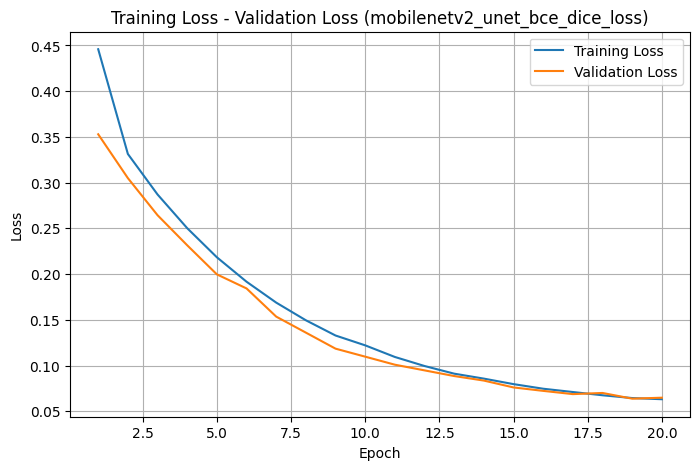

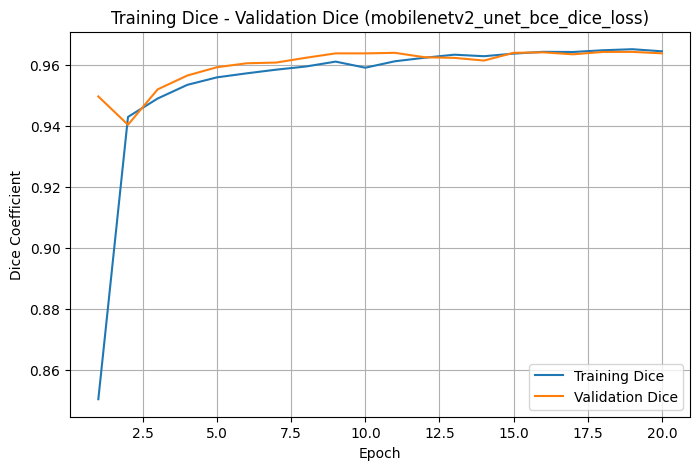

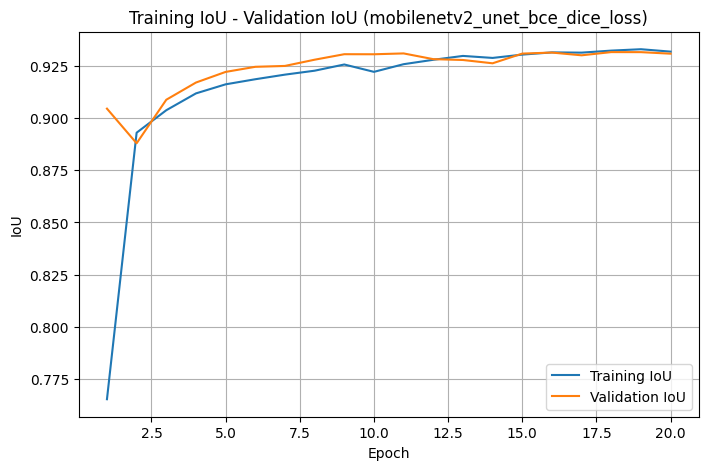

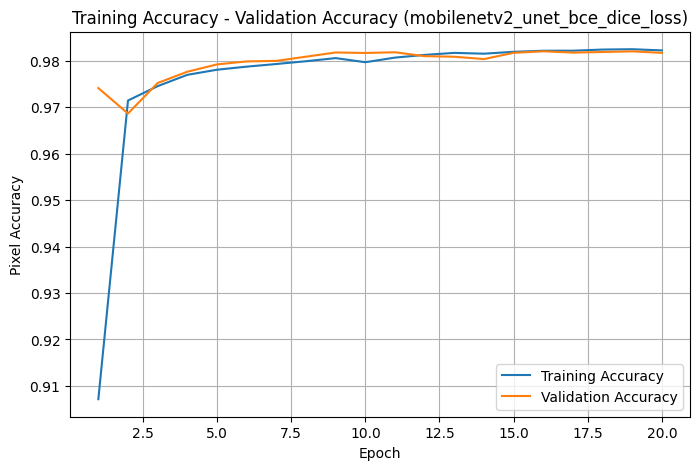


MobileNetV2 U-Net Test Results
------------------------------
Test Loss:     0.0724
Test Dice:     0.9575
Test IoU:      0.9205
Test Accuracy: 0.9792


,Model,Encoder,Parameters,Training Time (sec),Best Val Dice,Best Val IoU,Best Val Accuracy,Test Loss,Test Dice,Test IoU,Test Accuracy
0,Lightweight U-Net,Custom CNN Encoder,1942289,193.049401,0.965247,0.933671,0.982673,0.058083,0.957483,0.920590,0.979300
1,MobileNetV2 U-Net,Pretrained MobileNetV2,5558977,213.327335,0.964167,0.931701,0.982015,0.072351,0.957480,0.920527,0.979184


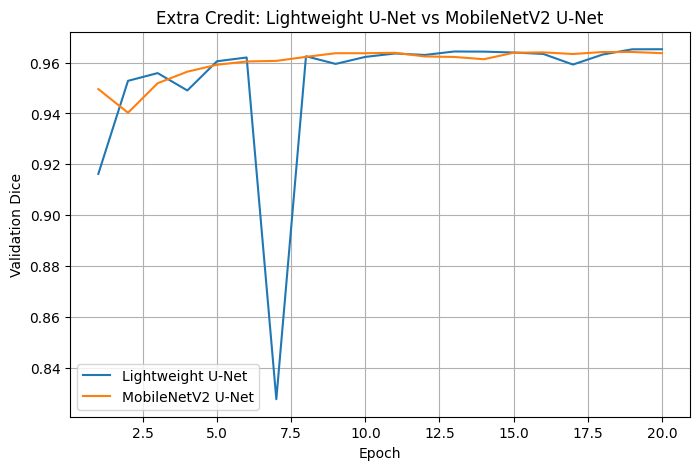


Step 18 completed.
Extra-credit comparison saved to:
outputs_q2/extra_credit_mobilenetv2_unet_comparison.csv
Figure saved to:
outputs_q2/extra_credit_val_dice_comparison.png


In [19]:
# ============================================================
# Question 2 - Step 18: Extra Credit
# U-Net with MobileNetV2 Encoder
# Compare with our Lightweight U-Net
# ============================================================

import time
import copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision import models
from torchvision.models import MobileNet_V2_Weights


# ------------------------------------------------------------
# 1. Helper convolution block for decoder
# ------------------------------------------------------------

class DecoderConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(DecoderConvBlock, self).__init__()

        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)


# ------------------------------------------------------------
# 2. MobileNetV2 Encoder U-Net
# Input images are grayscale [B, 1, H, W].
# MobileNetV2 expects 3 channels, so the input is repeated to 3 channels.
# ------------------------------------------------------------

class MobileNetV2UNet(nn.Module):
    def __init__(self, pretrained=True):
        super(MobileNetV2UNet, self).__init__()

        if pretrained:
            weights = MobileNet_V2_Weights.IMAGENET1K_V1
        else:
            weights = None

        mobilenet = models.mobilenet_v2(weights=weights)
        features = mobilenet.features

        # Encoder blocks from MobileNetV2
        self.enc0 = features[0]                     # 3 -> 32, 64x64
        self.enc1 = features[1]                     # 32 -> 16, 64x64
        self.enc2 = nn.Sequential(features[2], features[3])          # 16 -> 24, 32x32
        self.enc3 = nn.Sequential(features[4], features[5], features[6])  # 24 -> 32, 16x16
        self.enc4 = nn.Sequential(
            features[7], features[8], features[9], features[10],
            features[11], features[12], features[13]
        )                                           # 32 -> 96, 8x8
        self.bottleneck = nn.Sequential(
            features[14], features[15], features[16], features[17], features[18]
        )                                           # 96 -> 1280, 4x4

        # Decoder
        self.up5 = nn.ConvTranspose2d(1280, 256, kernel_size=2, stride=2)  # 4 -> 8
        self.dec5 = DecoderConvBlock(256 + 96, 256)

        self.up4 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)   # 8 -> 16
        self.dec4 = DecoderConvBlock(128 + 32, 128)

        self.up3 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)    # 16 -> 32
        self.dec3 = DecoderConvBlock(64 + 24, 64)

        self.up2 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)     # 32 -> 64
        self.dec2 = DecoderConvBlock(32 + 16, 32)

        self.up1 = nn.ConvTranspose2d(32, 16, kernel_size=2, stride=2)     # 64 -> 128
        self.dec1 = DecoderConvBlock(16, 16)

        self.final_conv = nn.Conv2d(16, 1, kernel_size=1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # Convert grayscale to 3-channel input for MobileNetV2
        if x.shape[1] == 1:
            x_rgb = x.repeat(1, 3, 1, 1)
        else:
            x_rgb = x

        # Encoder
        e0 = self.enc0(x_rgb)      # [B, 32, 64, 64]
        e1 = self.enc1(e0)         # [B, 16, 64, 64]
        e2 = self.enc2(e1)         # [B, 24, 32, 32]
        e3 = self.enc3(e2)         # [B, 32, 16, 16]
        e4 = self.enc4(e3)         # [B, 96, 8, 8]
        b = self.bottleneck(e4)    # [B, 1280, 4, 4]

        # Decoder with skip connections
        d5 = self.up5(b)
        d5 = torch.cat([d5, e4], dim=1)
        d5 = self.dec5(d5)

        d4 = self.up4(d5)
        d4 = torch.cat([d4, e3], dim=1)
        d4 = self.dec4(d4)

        d3 = self.up3(d4)
        d3 = torch.cat([d3, e2], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e1], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = self.dec1(d1)

        out = self.final_conv(d1)
        out = self.sigmoid(out)

        return out


# ------------------------------------------------------------
# 3. Create model and count parameters
# ------------------------------------------------------------

mobilenet_unet = MobileNetV2UNet(pretrained=True).to(device)

mobilenet_total_params = sum(p.numel() for p in mobilenet_unet.parameters())
mobilenet_trainable_params = sum(p.numel() for p in mobilenet_unet.parameters() if p.requires_grad)

print("MobileNetV2 U-Net created.")
print(f"Total parameters: {mobilenet_total_params:,}")
print(f"Trainable parameters: {mobilenet_trainable_params:,}")

# Test one forward pass
sample_images, sample_masks = next(iter(train_aug_loader_q2))
sample_images = sample_images.to(device)

with torch.no_grad():
    sample_outputs = mobilenet_unet(sample_images)

print("Input shape:", sample_images.shape)
print("Output shape:", sample_outputs.shape)
print("Output min/max:", sample_outputs.min().item(), sample_outputs.max().item())


# ------------------------------------------------------------
# 4. Train MobileNetV2 U-Net
# ------------------------------------------------------------

mobilenet_bce_dice_loss = BCEDiceLoss(
    bce_weight=0.5,
    dice_weight=0.5
)

mobilenet_unet, history_mobilenet_unet, time_mobilenet_unet = train_segmentation_model(
    model=mobilenet_unet,
    train_loader=train_aug_loader_q2,
    val_loader=val_loader_q2,
    criterion=mobilenet_bce_dice_loss,
    model_name="mobilenetv2_unet_bce_dice_loss",
    num_epochs=20,
    learning_rate=0.0003,
    weight_decay=1e-4,
    patience=5
)

plot_segmentation_history(
    history=history_mobilenet_unet,
    model_name="mobilenetv2_unet_bce_dice_loss"
)


# ------------------------------------------------------------
# 5. Test evaluation of MobileNetV2 U-Net
# ------------------------------------------------------------

test_loss_mobilenet, test_dice_mobilenet, test_iou_mobilenet, test_acc_mobilenet = evaluate_segmentation_model(
    model=mobilenet_unet,
    data_loader=test_loader_q2,
    criterion=mobilenet_bce_dice_loss,
    device=device,
    desc="Testing MobileNetV2 U-Net"
)

print("\nMobileNetV2 U-Net Test Results")
print("------------------------------")
print(f"Test Loss:     {test_loss_mobilenet:.4f}")
print(f"Test Dice:     {test_dice_mobilenet:.4f}")
print(f"Test IoU:      {test_iou_mobilenet:.4f}")
print(f"Test Accuracy: {test_acc_mobilenet:.4f}")


# ------------------------------------------------------------
# 6. Load / define Lightweight U-Net final values
# These values come from previous steps.
# ------------------------------------------------------------

lightweight_params = 1_942_289
lightweight_time = time_unet_skip_bce_dice
lightweight_test_loss = 0.058083
lightweight_test_dice = 0.957483
lightweight_test_iou = 0.920590
lightweight_test_acc = 0.979300

# Validation values from previous comparison
history_lightweight_df = pd.read_csv("outputs_q2/history_unet_skip_bce_dice_loss.csv")
lightweight_best_val_dice = history_lightweight_df["val_dice_coef"].max()
lightweight_best_val_iou = history_lightweight_df["val_iou"].max()
lightweight_best_val_acc = history_lightweight_df["val_accuracy"].max()


# MobileNet validation values
history_mobilenet_df = pd.DataFrame(history_mobilenet_unet)
mobilenet_best_val_dice = max(history_mobilenet_unet["val_dice_coef"])
mobilenet_best_val_iou = max(history_mobilenet_unet["val_iou"])
mobilenet_best_val_acc = max(history_mobilenet_unet["val_accuracy"])


# ------------------------------------------------------------
# 7. Final extra-credit comparison table
# ------------------------------------------------------------

extra_credit_comparison_df = pd.DataFrame([
    {
        "Model": "Lightweight U-Net",
        "Encoder": "Custom CNN Encoder",
        "Parameters": lightweight_params,
        "Training Time (sec)": lightweight_time,
        "Best Val Dice": lightweight_best_val_dice,
        "Best Val IoU": lightweight_best_val_iou,
        "Best Val Accuracy": lightweight_best_val_acc,
        "Test Loss": lightweight_test_loss,
        "Test Dice": lightweight_test_dice,
        "Test IoU": lightweight_test_iou,
        "Test Accuracy": lightweight_test_acc
    },
    {
        "Model": "MobileNetV2 U-Net",
        "Encoder": "Pretrained MobileNetV2",
        "Parameters": mobilenet_total_params,
        "Training Time (sec)": time_mobilenet_unet,
        "Best Val Dice": mobilenet_best_val_dice,
        "Best Val IoU": mobilenet_best_val_iou,
        "Best Val Accuracy": mobilenet_best_val_acc,
        "Test Loss": test_loss_mobilenet,
        "Test Dice": test_dice_mobilenet,
        "Test IoU": test_iou_mobilenet,
        "Test Accuracy": test_acc_mobilenet
    }
])

display(extra_credit_comparison_df)

extra_credit_comparison_df.to_csv(
    "outputs_q2/extra_credit_mobilenetv2_unet_comparison.csv",
    index=False
)


# ------------------------------------------------------------
# 8. Plot validation Dice comparison
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(history_lightweight_df) + 1),
    history_lightweight_df["val_dice_coef"],
    label="Lightweight U-Net"
)
plt.plot(
    range(1, len(history_mobilenet_unet["val_dice_coef"]) + 1),
    history_mobilenet_unet["val_dice_coef"],
    label="MobileNetV2 U-Net"
)
plt.xlabel("Epoch")
plt.ylabel("Validation Dice")
plt.title("Extra Credit: Lightweight U-Net vs MobileNetV2 U-Net")
plt.legend()
plt.grid(True)
plt.savefig("outputs_q2/extra_credit_val_dice_comparison.png", dpi=300)
plt.show()

print("\nStep 18 completed.")
print("Extra-credit comparison saved to:")
print("outputs_q2/extra_credit_mobilenetv2_unet_comparison.csv")
print("Figure saved to:")
print("outputs_q2/extra_credit_val_dice_comparison.png")
